<a href="https://colab.research.google.com/github/gargi510/Wikipedia_Page_Views_Forecasting-AdEase/blob/main/adsense_timeseries_non_plotly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement  

**AdEase** is a **digital advertising company** leveraging AI to maximize engagement cost-effectively.  

The objective for the Data Science team is to analyze and forecast Wikipedia page views to optimize ad placements across languages and regions.  



# Data Dictionary  

- **train_1.csv**  
  - Rows → Wikipedia articles  
  - Columns → Dates (daily views per article)  
  - `Page` format: `NAME_LANGUAGE.wikipedia.org_ACCESS_TYPE_ACCESS_ORIGIN`  

- **Exog_Campaign_eng.csv**  
  - Binary indicator for campaigns/events
  - `1` = campaign/event day, `0` = normal day  
  - Used as an exogenous variable in forecasting  
  - To be used only for English


# Approach

1. **Data Cleaning:** Handle missing values, remove irrelevant or unknown languages, and prepare time series for modeling.  
2. **Exploratory Data Analysis (EDA):** Understand historical trends, seasonality, peaks, and traffic patterns across pages and languages.  
3. **Forecast Future Page Views:** Build models to accurately predict user engagement for upcoming periods.  
4. **Segment by Language and Region:** Analyze and forecast separately for each language and region to tailor insights for client needs.  
5. **Stationarity Check & Differencing:** Perform ADF tests and apply differencing as needed to stabilize the time series.  
6. **Model Building:** Fit multiple time series forecasting models including ARIMA, SARIMA, and Prophet to capture trend and seasonal components.  
7. **Forecast Evaluation:** Calculate MAPE (or SMAPE) on test data to compare model accuracy and select the best-performing model per language.  
8. **Hyperparameter Tuning:** Allow customization of ARIMA/SARIMA orders and Prophet seasonality per language for better accuracy.  
9. **Pipeline Development:** Create a modular pipeline to automate forecasting across multiple languages and use cases, enabling scalability and reproducibility.  
10. **Insights & Recommendations:** Generate actionable outputs to optimize ad placements, align with business goals, and support strategic decision-making.  


# Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importing necessary Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")


# Data Structure

In [3]:
file_path = "/content/drive/MyDrive/Colab Notebooks/Ad Sense/train_1.csv"

df = pd.read_csv(file_path)
df.head()


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


Some Null values can be seen in the data which needs to be handled.

Page column looks like a combination of multiple clolumns.

In [4]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 551 entries, Page to 2016-12-31
dtypes: float64(550), object(1)
memory usage: 609.8+ MB
None
(145063, 551)


Data frame has 145063 records ans 551 columns

# Data Cleaning

## Feature Engineering

Split the Data in 'Page' column by using '_' as separator. Make new columns: Page_Name, Language, Domain, Access_Type, Access_Origin

In [5]:
split_cols = df['Page'].str.rsplit('_', n=3, expand=True)

df['Page_Name'] = split_cols[0]
df['Language_Domain'] = split_cols[1]
df['Access_Type'] = split_cols[2]
df['Access_Origin'] = split_cols[3]

df['Language'] = df['Language_Domain'].str[:2]

df['Domain'] = df['Language_Domain'].str.split('.', n=1).str[1]

df[['Page', 'Page_Name', 'Language', 'Domain', 'Access_Type', 'Access_Origin']].head()


,Page,Page_Name,Language,Domain,Access_Type,Access_Origin
0,2NE1_zh.wikipedia.org_all-access_spider,2NE1,zh,wikipedia.org,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,2PM,zh,wikipedia.org,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,3C,zh,wikipedia.org,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,4minute,zh,wikipedia.org,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,52_Hz_I_Love_You,zh,wikipedia.org,all-access,spider


In [6]:
df[df['Language'] == 'ww'].head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-28,2016-12-29,2016-12-30,2016-12-31,Page_Name,Language_Domain,Access_Type,Access_Origin,Language,Domain
19611,"""Keep_me_logged_in""_extended_to_one_year_www.m...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,14.0,7.0,12.0,"""Keep_me_logged_in""_extended_to_one_year",www.mediawiki.org,all-access,all-agents,ww,mediawiki.org
19612,2017_wikitext_editor_www.mediawiki.org_all-acc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,52.0,43.0,100.0,73.0,2017_wikitext_editor,www.mediawiki.org,all-access,all-agents,ww,mediawiki.org
19613,2017_wikitext_editor/Feedback_www.mediawiki.or...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,32.0,41.0,19.0,2017_wikitext_editor/Feedback,www.mediawiki.org,all-access,all-agents,ww,mediawiki.org
19614,API_www.mediawiki.org_all-access_all-agents,528.0,587.0,634.0,483.0,510.0,559.0,625.0,594.0,565.0,...,334.0,351.0,358.0,275.0,API,www.mediawiki.org,all-access,all-agents,ww,mediawiki.org
19615,API:Account_creation_www.mediawiki.org_all-acc...,37.0,38.0,46.0,41.0,79.0,91.0,100.0,54.0,43.0,...,38.0,28.0,45.0,41.0,API:Account_creation,www.mediawiki.org,all-access,all-agents,ww,mediawiki.org


Check the records in 'ww' language. It looks like a special language

In [7]:
df.drop(columns=['Page','Language_Domain'], inplace=True)
df.head()

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,Page_Name,Access_Type,Access_Origin,Language,Domain
0,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,24.0,...,20.0,22.0,19.0,18.0,20.0,2NE1,all-access,spider,zh,wikipedia.org
1,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,4.0,...,30.0,52.0,45.0,26.0,20.0,2PM,all-access,spider,zh,wikipedia.org
2,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,4.0,...,4.0,6.0,3.0,4.0,17.0,3C,all-access,spider,zh,wikipedia.org
3,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,16.0,...,11.0,17.0,19.0,10.0,11.0,4minute,all-access,spider,zh,wikipedia.org
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.0,27.0,13.0,36.0,10.0,52_Hz_I_Love_You,all-access,spider,zh,wikipedia.org


Check the structure of new table

In [8]:
df.shape

(145063, 555)

New dataframe has 145063 records and 555 columns which includes the newly created columns by spliting the Page field.

Check and upload the Exog_Campaign_eng file

In [9]:
file_path = "/content/drive/MyDrive/Colab Notebooks/Ad Sense/Exog_Campaign_eng"

df2 = pd.read_csv(file_path)
df2.head()


,Exog
0,0
1,0
2,0
3,0
4,0


Check the shape of the file

In [10]:
df2.shape

(550, 1)

In [11]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Exog    550 non-null    int64
dtypes: int64(1)
memory usage: 4.4 KB


It has 550 records and only 1 column with values 0 or 1 of int datatype. These 550 fields corresponds to the 550 date columns we have in our train dataset.

## Checking duplicate Values

In [12]:
df.duplicated().sum()

np.int64(0)

No duplicate records found

In [13]:
df.dtypes.sample(10)

,0
2016-05-09,float64
2015-12-08,float64
2016-06-26,float64
2016-12-21,float64
2016-01-27,float64
2015-08-17,float64
2015-11-21,float64
2016-03-08,float64
2016-09-11,float64
2015-10-12,float64


##Missing Value Handling

Checking if all the dates are present in the data or there is some missing value

In [14]:
df_dates = pd.to_datetime(df.columns[:-5])
date_cols = df.columns[:-5]

all_dates = pd.date_range(start=df_dates.min(), end=df_dates.max(), freq='D')  # daily
missing_dates = set(all_dates) - set(df_dates)
print("Missing dates:", missing_dates)


Missing dates: set()


Plotting the missing values(NULLs) in the dataset

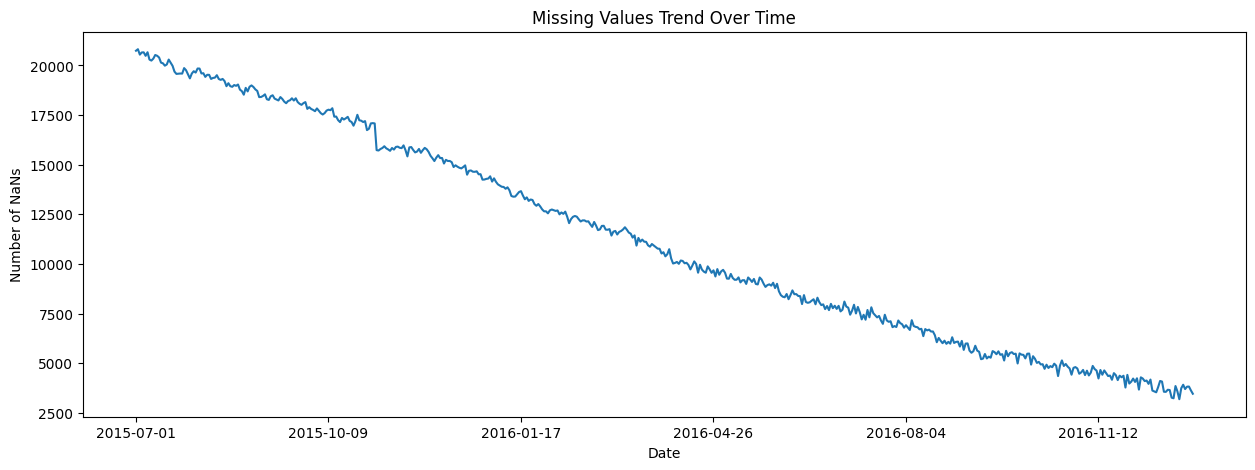

In [15]:
missing_trend = df[date_cols].isna().sum()

missing_trend.plot(figsize=(15,5))
plt.title("Missing Values Trend Over Time")
plt.ylabel("Number of NaNs")
plt.xlabel("Date")
plt.show()


In [16]:
print("First 10 days missing:", missing_trend.head(10).mean())
print("Last 10 days missing:", missing_trend.tail(10).mean())

First 10 days missing: 20544.0
Last 10 days missing: 3673.7


Missing values show a decreasing trend over time. To analyze this further, we will group the data into 6-month intervals and classify missingness into three categories: >50%, 20–50%, and ≤20%. This will help us understand the patterns and determine the most appropriate handling strategy.

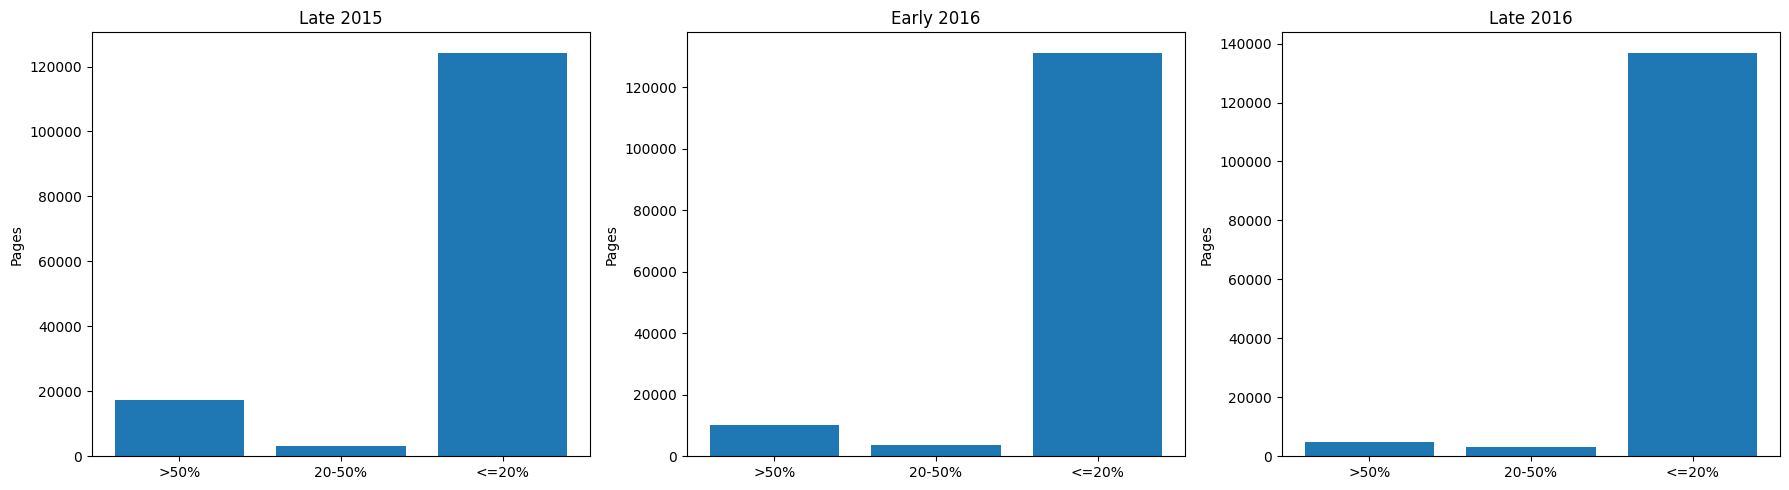

In [17]:
def cat(x): return '>50%' if x>0.5 else '20-50%' if x>0.2 else '<=20%'

# Define chunks as 6-month spans but use custom labels
chunks, labels = [], ['Late 2015', 'Early 2016', 'Late 2016']
curr = df_dates.min()

for _ in labels:
    nxt = curr + pd.DateOffset(months=6)
    cols = date_cols[(df_dates >= curr) & (df_dates < nxt)]
    if len(cols): chunks.append(cols)
    curr = nxt

plt.figure(figsize=(6*len(chunks),5))

for i,(cols,label) in enumerate(zip(chunks, labels),1):
    bins = df[cols].isna().mean(1).apply(cat).value_counts()\
                        .reindex(['>50%','20-50%','<=20%'], fill_value=0)
    plt.subplot(1,len(chunks),i)
    plt.bar(bins.index, bins.values)
    plt.title(label)
    plt.ylabel("Pages")

plt.tight_layout()
plt.show()


Key insights:

Most pages (>124k) have ≤20% missing — dataset is largely usable.

Pages with >50% missing decrease over time (17k → 5k) — likely because newer pages are created with more complete data, older pages may have historical gaps.

Pages with moderate missingness (20–50%) are fairly stable (~3k) — small group consistently partially missing.

To handle missing values in pages, we follow this approach:

1. **Drop pages with >50% missing** → too sparse to model.  
2. **Fill early NaNs** (before the first valid value) with `0` → represents structural missingness (page didn’t exist).  
3. **Interpolate middle/late NaNs** → smooth sporadic gaps in the series.  
4. **Forward/backward fill edge NaNs** → handle any remaining missing values.



In [18]:
def handle_page_missing_values(df, date_cols):
    df[date_cols] = df[date_cols].apply(pd.to_numeric, errors='coerce')

    df['missing_fraction'] = df[date_cols].isna().mean(axis=1)
    pages_dropped = df[df['missing_fraction'] > 0.5].shape[0]
    df = df[df['missing_fraction'] <= 0.5]

    def fill_early_nans(row):
        values = row.values
        first_valid_idx = np.argmax(~pd.isna(values)) if np.any(~pd.isna(values)) else len(values)
        values[:first_valid_idx] = 0
        return values

    df[date_cols] = df[date_cols].apply(fill_early_nans, axis=1, result_type='expand')
    df[date_cols] = df[date_cols].interpolate(axis=1, method='linear')
    df[date_cols] = df[date_cols].ffill(axis=1).bfill(axis=1)

    df = df.drop(columns=['missing_fraction'])
    print(f"Pages dropped (>50% missing): {pages_dropped}")
    return df

df_cleaned = handle_page_missing_values(df, date_cols)
print("Total missing values after handling:", df_cleaned[date_cols].isna().sum().sum())

Pages dropped (>50% missing): 10484
Total missing values after handling: 0


In [19]:
total_nan = df_cleaned.isna().sum().sum()
print("Total number of NaNs in the dataset:", total_nan)


Total number of NaNs in the dataset: 0


A total of 10,484 pages were dropped from the dataset because they had more than 50% missing values and were too sparse to use. After handling, the remaining dataset contains no null values.

Check the final structure of the table

In [20]:
print(df_cleaned.info())
print(df_cleaned.head())

<class 'pandas.core.frame.DataFrame'>
Index: 134579 entries, 0 to 145020
Columns: 555 entries, 2015-07-01 to Domain
dtypes: float64(550), object(5)
memory usage: 570.9+ MB
None
   2015-07-01  2015-07-02  2015-07-03  2015-07-04  2015-07-05  2015-07-06  \
0        18.0        11.0         5.0        13.0        14.0         9.0   
1        11.0        14.0        15.0        18.0        11.0        13.0   
2         1.0         0.0         1.0         1.0         0.0         4.0   
3        35.0        13.0        10.0        94.0         4.0        26.0   
5        12.0         7.0         4.0         5.0        20.0         8.0   

   2015-07-07  2015-07-08  2015-07-09  2015-07-10  ...  2016-12-27  \
0         9.0        22.0        26.0        24.0  ...        20.0   
1        22.0        11.0        10.0         4.0  ...        30.0   
2         0.0         3.0         4.0         4.0  ...         4.0   
3        14.0         9.0        11.0        16.0  ...        11.0   
5         

## Final Dataset Overview

- After cleaning, the dataset has **134,579 pages**. We removed about **10,484 pages** that had more than 50% missing values.  
- There are **550 daily columns** from **July 2015 to December 2016**, and **all missing values have been handled** (early NaNs filled with 0, middle/late NaNs linearly interpolated, edges forward/backward filled).  
- From the original `Page` column, we created **5 new columns** by splitting on the underscore:
  - `Page_Name` – actual page name  
  - `Language` – page language  
  - `Domain` – website domain  
  - `Access_Type` – type of access  
  - `Access_Origin` – source of access  
- There are **no duplicate rows**.  
- All **date columns are continuous**, so the dataset is ready for **time series analysis**.  

**Summary:** The table is clean, complete, and structured for both page-level analysis and time series modeling.


# EDA

## Metadata Summary

In [21]:
language_map = {
    'en': 'English',
    'ja': 'Japanese',
    'de': 'German',
    'fr': 'French',
    'zh': 'Chinese',
    'ru': 'Russian',
    'es': 'Spanish',
    'co': 'Corsican',
    'ww': 'Unknown'
}

df_cleaned['Language_Full'] = df_cleaned['Language'].map(language_map)
language_counts_full = df_cleaned['Language_Full'].value_counts()

<Axes: ylabel='Access_Origin'>

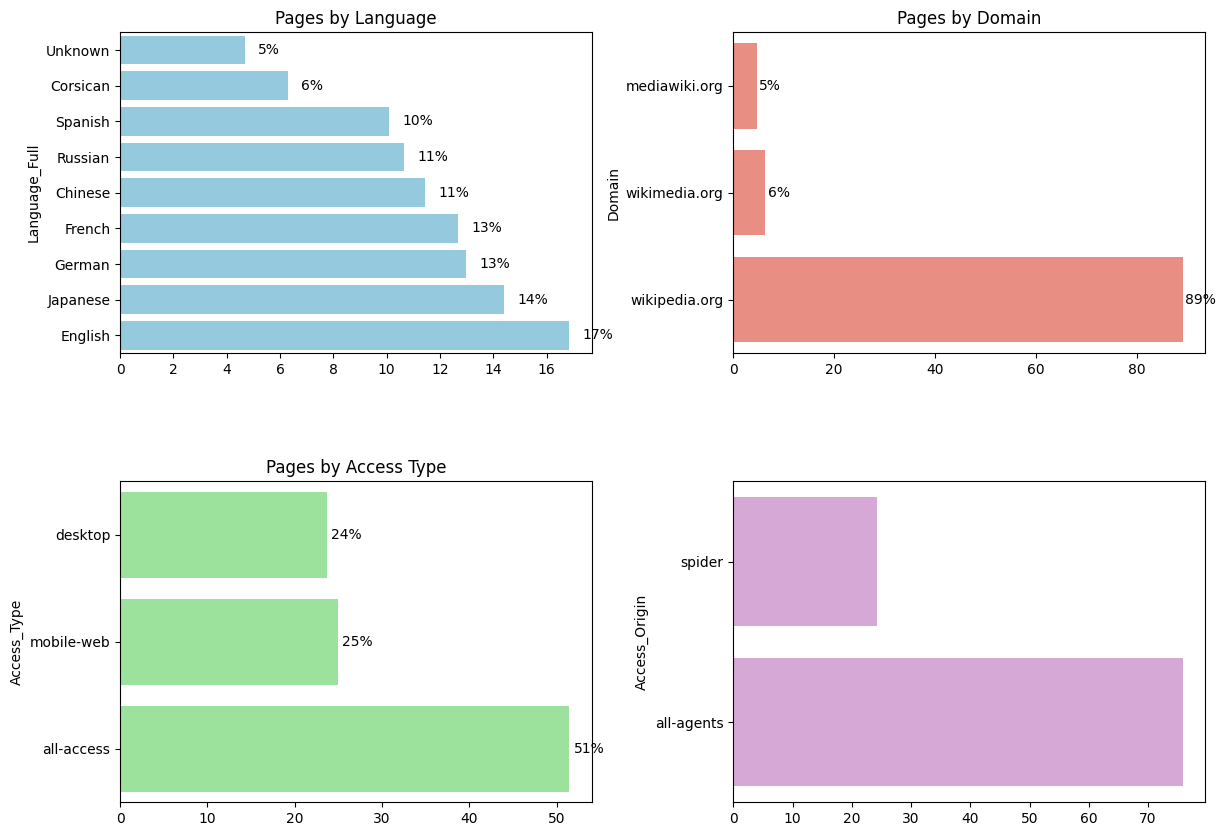

In [44]:
language_counts = df_cleaned['Language_Full'].value_counts()
language_percent = (language_counts / language_counts.sum() * 100).sort_values()

domain_counts = df_cleaned['Domain'].value_counts()
domain_percent = (domain_counts / domain_counts.sum() * 100).sort_values()

access_type_counts = df_cleaned['Access_Type'].value_counts()
access_type_percent = (access_type_counts / access_type_counts.sum() * 100).sort_values()

access_origin_counts = df_cleaned['Access_Origin'].value_counts()
access_origin_percent = (access_origin_counts / access_origin_counts.sum() * 100).sort_values()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

sns.barplot(x=language_percent.values, y=language_percent.index, ax=axes[0,0], color='skyblue')
axes[0,0].set_title("Pages by Language")
for i, v in enumerate(language_percent.values):
    axes[0,0].text(v + 0.5, i, f"{round(v)}%", va='center')

sns.barplot(x=domain_percent.values, y=domain_percent.index, ax=axes[0,1], color='salmon')
axes[0,1].set_title("Pages by Domain")
for i, v in enumerate(domain_percent.values):
    axes[0,1].text(v + 0.5, i, f"{round(v)}%", va='center')

sns.barplot(x=access_type_percent.values, y=access_type_percent.index, ax=axes[1,0], color='lightgreen')
axes[1,0].set_title("Pages by Access Type")
for i, v in enumerate(access_type_percent.values):
    axes[1,0].text(v + 0.5, i, f"{round(v)}%", va='center')

sns.barplot(x=access_origin_percent.values, y=access_origin_percent.index, ax=axes[1,1], color='plum')


### Number of pages by Language, Domain, Access Type, Access Origin

1. **Language Distribution:** Most pages are in English, followed by Japanese, with German and French roughly tied.  
2. **Domain:** Majority of pages are from Wikipedia.org.  
3. **Access Type:** About 51% of pages have all-access, 25% are mobile-web, and 24% are desktop.  
4. **Access Origin:** Around 24% of pages originate from spiders, while 76% come from all agents.  

The above percentages are based on the data splits, but the graph is dynamic using Plotly. By hovering over the graph, you can see the actual values for each category.


## Overall Daily, Weekly and Monthly Views

Using Timestamp categorize the records in Daily, monthly and weekly recods then create a time series chart

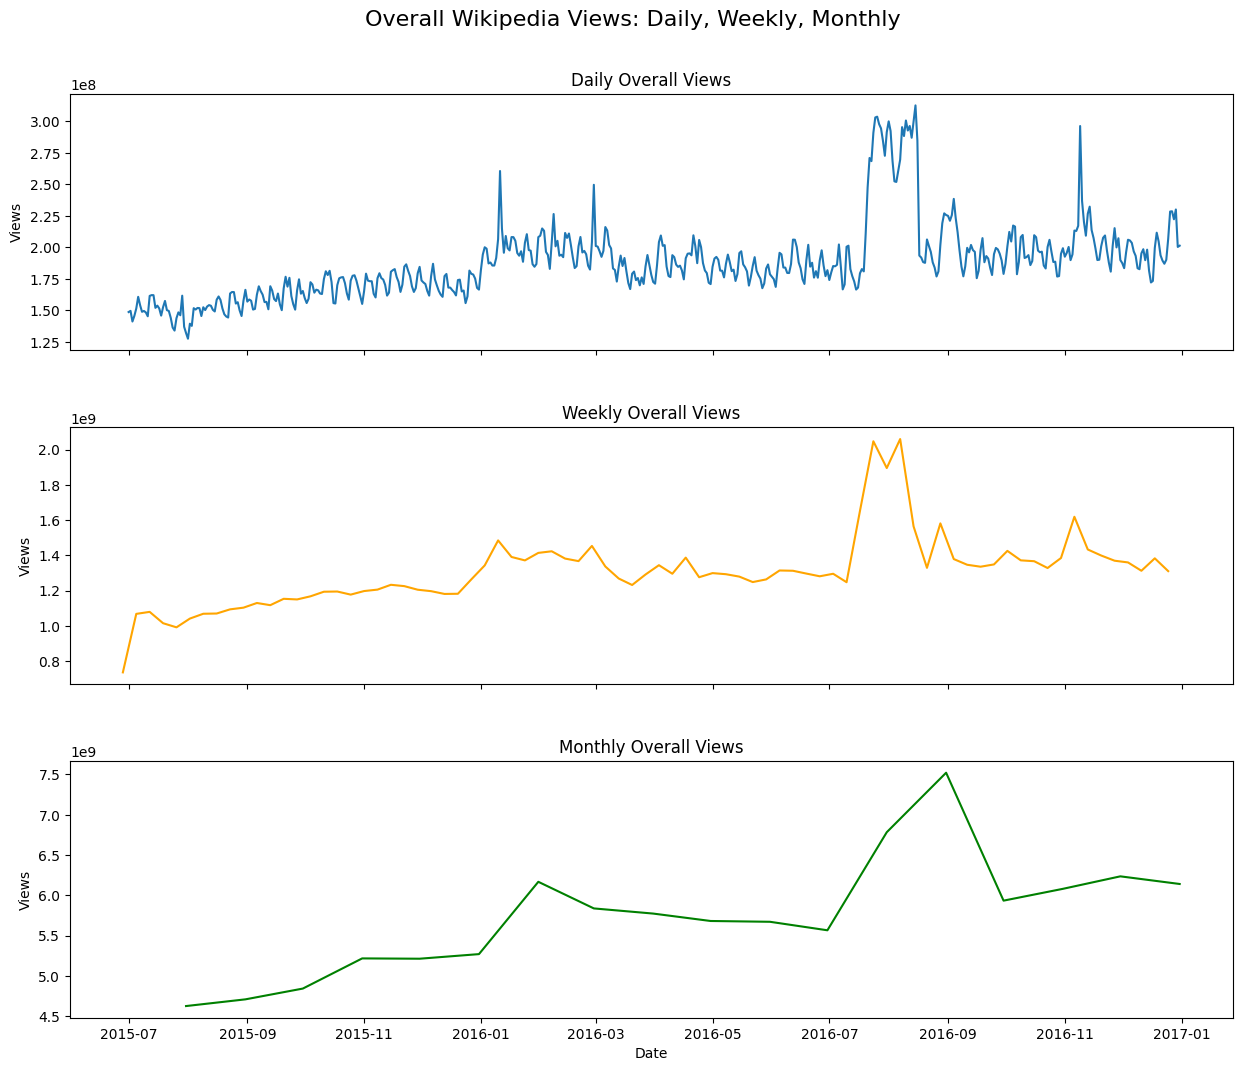

In [41]:
overall_ts = df_cleaned[date_cols].sum()
overall_ts.index = pd.to_datetime(overall_ts.index)

overall_ts_daily = overall_ts
overall_ts_weekly = overall_ts.resample('W', label='left').sum()
overall_ts_monthly = overall_ts.resample('M').sum()


fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
plt.subplots_adjust(hspace=0.3)

sns.lineplot(x=overall_ts_daily.index, y=overall_ts_daily.values, ax=axes[0])
axes[0].set_title("Daily Overall Views")
axes[0].set_ylabel("Views")


sns.lineplot(x=overall_ts_weekly.index, y=overall_ts_weekly.values, ax=axes[1], color='orange')
axes[1].set_title("Weekly Overall Views")
axes[1].set_ylabel("Views")

sns.lineplot(x=overall_ts_monthly.index, y=overall_ts_monthly.values, ax=axes[2], color='green')
axes[2].set_title("Monthly Overall Views")
axes[2].set_ylabel("Views")
axes[2].set_xlabel("Date")


plt.suptitle("Overall Wikipedia Views: Daily, Weekly, Monthly", fontsize=16, y=0.95)
plt.show()


### Analysis
- **Daily Trends:** The dataset shows spikes on **Jan 11, Feb 29, July 26, Aug 15, and Nov 9 (2016)**. These may correspond to specific events, holidays, or high-traffic periods that drove user activity.  

- **Monthly Trends:** There is a clear **peak at the end of Jan 2016**, likely due to post-holiday activity, and an even larger peak in **Aug 2016**, suggesting increased user engagement during summer.  

- **Weekly Trends:** A sharp rise is observed from the week of **July 10 to July 24**, continuing through the week of **Aug 7**, followed by a **sudden drop** the next week. This indicates a **short-term surge in interest or activity**, possibly driven by seasonal events, campaigns, or trending topics.  

**Insight:** Overall, the dataset demonstrates **periodic spikes in activity**, with notable peaks in **January, July, and August 2016**. These patterns can help in **forecasting, seasonal modeling, and identifying high-traffic periods** for pages.


## Daily, Weekly, Monthly Views by Language

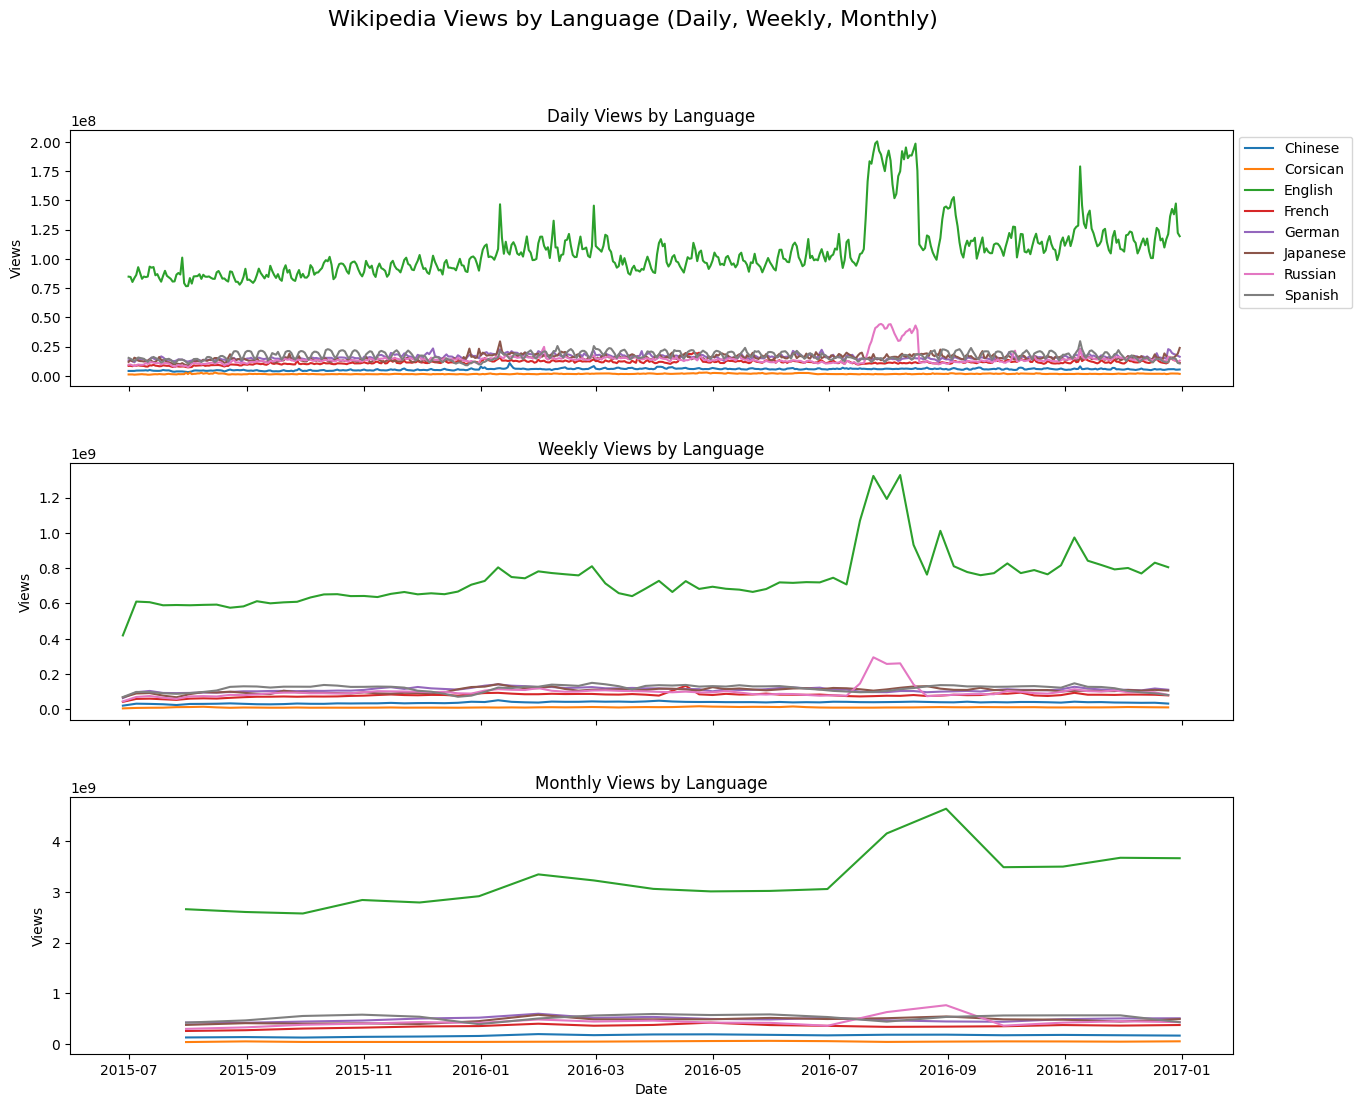

In [45]:
date_cols = [col for col in df_cleaned.columns if col[:4].isdigit()]

valid_langs = df_cleaned[~df_cleaned['Language_Full'].isin(['Unknown'])]
language_ts = valid_langs.groupby('Language_Full')[date_cols].sum().T
language_ts.index = pd.to_datetime(language_ts.index)

language_weekly = language_ts.resample('W', label='left').sum()
language_monthly = language_ts.resample('M').sum()

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
plt.subplots_adjust(hspace=0.3)

colors = sns.color_palette("tab10", n_colors=len(language_ts.columns))

for i, lang in enumerate(language_ts.columns):
    axes[0].plot(language_ts.index, language_ts[lang], label=lang, color=colors[i])
axes[0].set_title("Daily Views by Language")
axes[0].set_ylabel("Views")
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

for i, lang in enumerate(language_ts.columns):
    axes[1].plot(language_weekly.index, language_weekly[lang], label=lang, color=colors[i])
axes[1].set_title("Weekly Views by Language")
axes[1].set_ylabel("Views")

for i, lang in enumerate(language_ts.columns):
    axes[2].plot(language_monthly.index, language_monthly[lang], label=lang, color=colors[i])
axes[2].set_title("Monthly Views by Language")
axes[2].set_ylabel("Views")
axes[2].set_xlabel("Date")

fig.suptitle("Wikipedia Views by Language (Daily, Weekly, Monthly)", fontsize=16)
plt.show()


### Language-wise Time Series Analysis- Total Views

- On splitting the data by language, we observe that the **July–August 2016 peak** is most prominent in **English and Russian** pages.  
- The **December–January peak** is noticeable in **English and Japanese** pages.  
- Overall, English remains the dominant language across the dataset.


We drop the second-last to sixth-last columns(all metadata except newly created Language_Full field) from df_cleaned to keep only the columns needed for analysis.
Then, Creates df_language as a copy of the filtered DataFrame so the original data remains unchanged.

In [25]:
cols_to_keep = df_cleaned.columns.drop(df_cleaned.columns[-6:-1])
df_language = df_cleaned[cols_to_keep].copy()
df_language.head()

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,Language_Full
0,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,24.0,...,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0,Chinese
1,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,4.0,...,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0,Chinese
2,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,4.0,...,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0,Chinese
3,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,16.0,...,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0,Chinese
5,12.0,7.0,4.0,5.0,20.0,8.0,5.0,17.0,24.0,7.0,...,27.0,8.0,17.0,32.0,19.0,23.0,17.0,17.0,50.0,Chinese


Now we group the data by the Language_Full column and calculate the mean of all pages for each language. We used the mean instead of count because English pages were far more numerous than other languages, so averaging gives a fairer perspective for comparing languages.

We then transpose the table so that dates appear in rows and languages in columns, creating a proper time series format. After that, we convert the first column to the index for easier data handling and analysis.

In [26]:
df_language=df_language.groupby('Language_Full').mean().T
df_language.reset_index(inplace=True)
df_language.set_index('index', inplace=True)
df_language.head()

Language_Full,Chinese,Corsican,English,French,German,Japanese,Russian,Spanish,Unknown
index,,,,,,,,,
2015-07-01,269.434152,134.825686,3736.092705,496.398239,760.219228,611.878238,660.238175,1125.326140,55.494355
2015-07-02,269.870076,139.337030,3724.054095,499.587963,749.875893,702.646550,671.667211,1075.437132,60.913413
2015-07-03,268.064193,136.024894,3535.696684,480.401927,719.723618,634.592774,622.539749,989.017653,51.735383
2015-07-04,270.649914,112.502690,3681.044288,513.491413,660.463284,797.308418,585.550002,928.540750,49.029928
2015-07-05,288.707120,125.125360,3801.691537,504.137168,767.781890,764.914666,623.592626,1009.828682,53.728221


Text(0, 0.5, 'Views per Page')

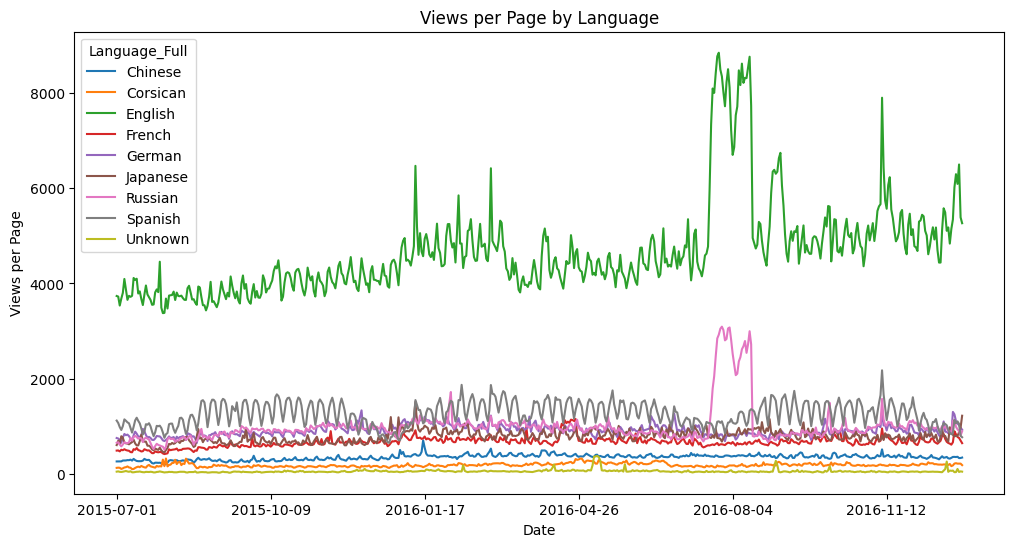

In [27]:
df_language.plot(figsize=(12,6))
plt.title('Views per Page by Language')
plt.xlabel('Date')
plt.ylabel('Views per Page')

### Language-wise Time Series Analysis – Views per Page

- On splitting the data by language, the **July–August 2016 peak** is most prominent in English and Russian pages.  
- The **December–January peak** is noticeable in English and Japanese pages.  
- Overall, English remains the dominant language across the dataset.  
- The data naturally separates into **three clear bands**:  
  - A **top band** dominated by English with consistently high and stable views.  
  - A **middle band** formed by languages like German, Russian, and Spanish that show moderate but fluctuating engagement.  
  - A **lower band** consisting of French, Chinese, Japanese, Corsican, and Unknown, which remain below 1,000 average views and show flatter patterns.  
- Since this analysis uses mean views, it provides a more balanced comparison across languages—unlike the count-based approach, which was heavily skewed toward English simply because it had far more pages. Using averages helps smaller languages stand out instead of being overshadowed by page volume differences.  
- These time-series patterns also align with broader daily, weekly, and monthly trends: English shows the strongest and most consistent cycles, German and Russian display sharp event-driven spikes, while lower-volume languages exhibit lower and steadier engagement.  
- Based on this clear separation in viewing patterns, and the scale and stability of English page views, the next phase of the analysis will focus specifically on English-language pages.


Plotting the graph just for English

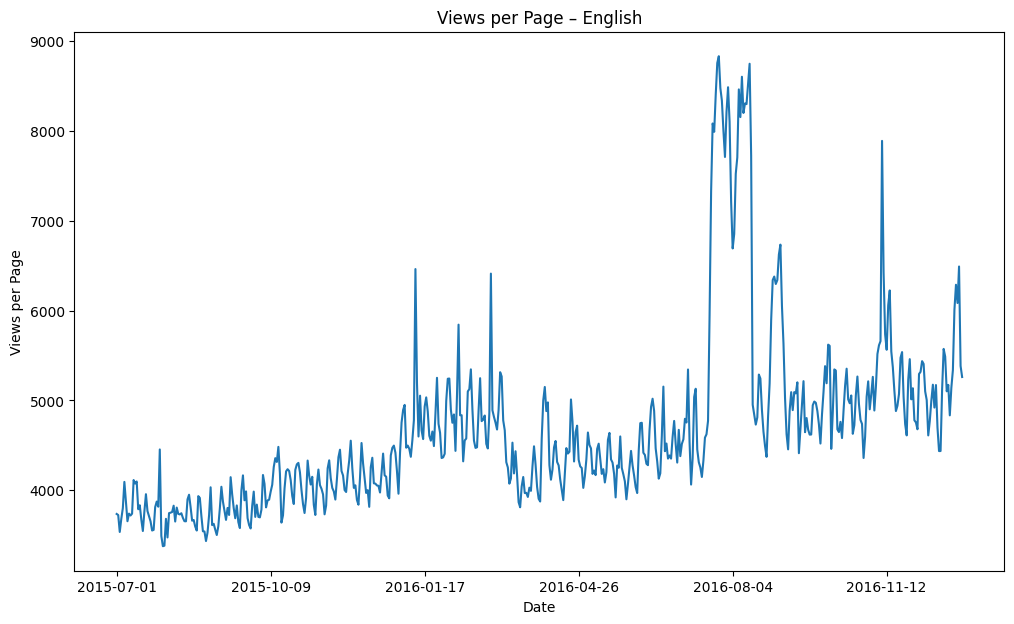

In [28]:
df_english = df_language['English']

df_english.plot(figsize=(12,7))
plt.title('Views per Page – English')
plt.ylabel('Views per Page')
plt.xlabel('Date')
plt.show()


# Stationarity

Now, we will run the Augmented Dickey–Fuller (ADF) test on the English time-series data to determine whether it is stationary or requires differencing for further analysis.

In [29]:
def df_test(x):
    result = adfuller(x)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')

df_test(df_english)

ADF Statistic: -2.351525
p-value: 0.155888
Critical Values:
   1%: -3.4426321555520905
   5%: -2.86695748394138
   10%: -2.5696553279762426


The p-value (0.156) > 0.05, so we fail to reject the null hypothesis.

This indicates that the English time-series is not stationary, meaning it has trends or seasonality that need to be removed (e.g., via differencing or detrending) before applying models like ARIMA.

##Time Series Decomposition

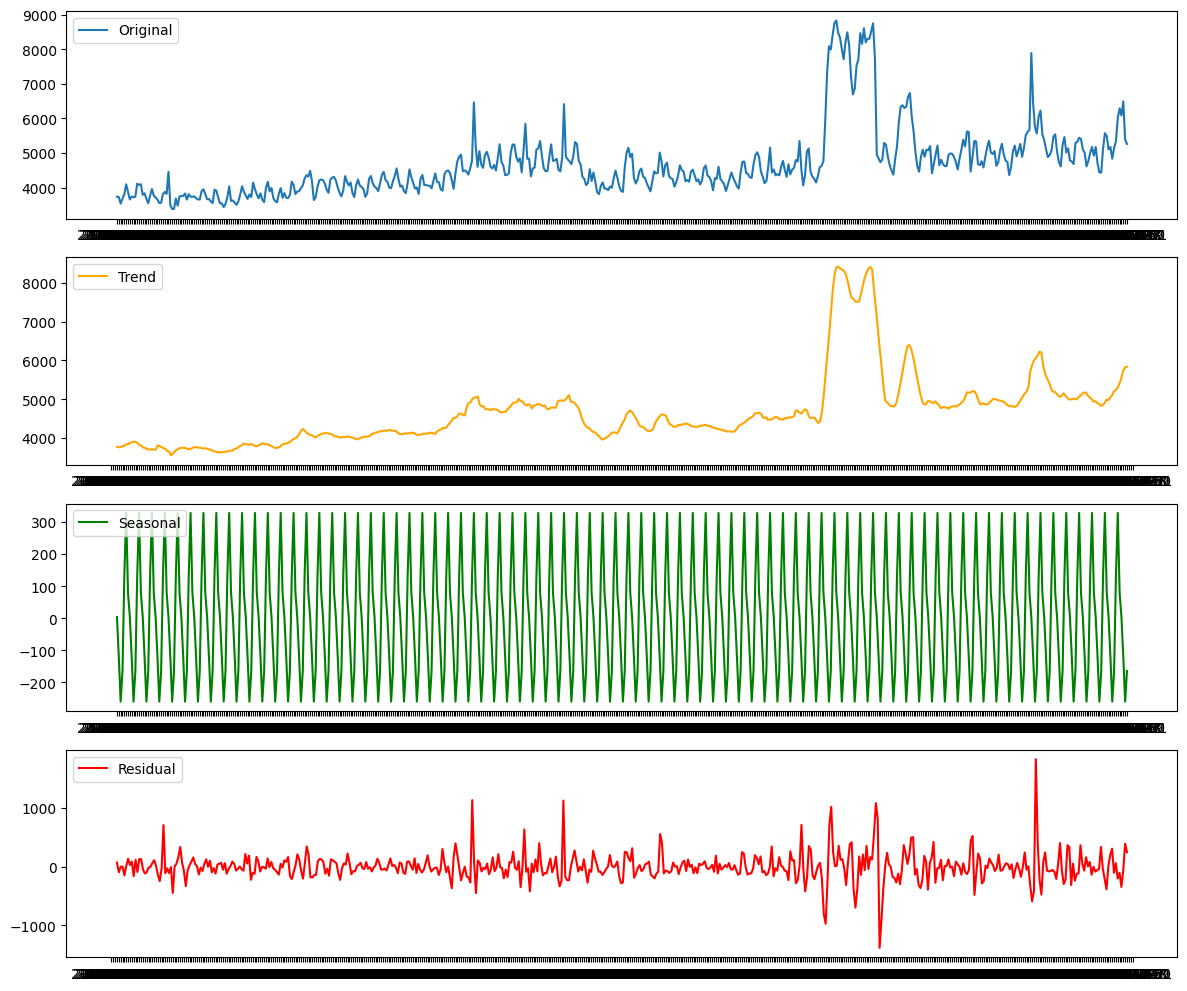

In [30]:
decomposition = seasonal_decompose(df_english, model='additive', period=7)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(12,10))

plt.subplot(4,1,1)
plt.plot(df_english, label='Original')
plt.legend(loc='upper left')

plt.subplot(4,1,2)
plt.plot(trend, label='Trend', color='orange')
plt.legend(loc='upper left')

plt.subplot(4,1,3)
plt.plot(seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')

plt.subplot(4,1,4)
plt.plot(residual, label='Residual', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

After Decomposition, it is clear that the data had weekly sesonality. Further, Lets check the stationarity of the residual to see if it is not stationary for further analysis.

In [31]:
df_residual = pd.DataFrame(residual)
df_residual.columns = ['Residual']
df_residual.index = df_english.index

result = adfuller(df_residual['Residual'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')


ADF Statistic: -11.436529131130754
p-value: 6.3279882310179245e-21
Critical Values:
   1%: -3.442843345332837
   5%: -2.867050445147657
   10%: -2.5697048674984457


The ADF statistic (-11.44) is much lower than all the critical values, and the p-value is effectively 0, which is well below the 0.05 threshold. This indicates that the residuals are strongly stationary, meaning the decomposition has successfully removed both trend and seasonality from the English time-series data. As a result, these residuals can now be safely used for modeling or further analysis, such as with ARIMA or other time-series methods.

## ACF PACF Plots

Before building the ARIMA model, we need to decide the values of p (AR order) and q (MA order). To determine these, we plot the ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) of the time series.

- The ACF plot shows the correlation of the series with its past values, including both direct and indirect correlations. It is particularly useful for identifying the MA (Moving Average) order, as MA models rely on correlations in past errors.

- The PACF plot shows the correlation of the series with its past values after removing the effects of intervening lags, i.e., the direct correlations. It is mainly used to determine the AR (Auto-Regressive) order.

By analyzing these two plots together, we can make informed decisions about the appropriate p and q values for the ARIMA model to capture both direct and indirect dependencies in the time series.


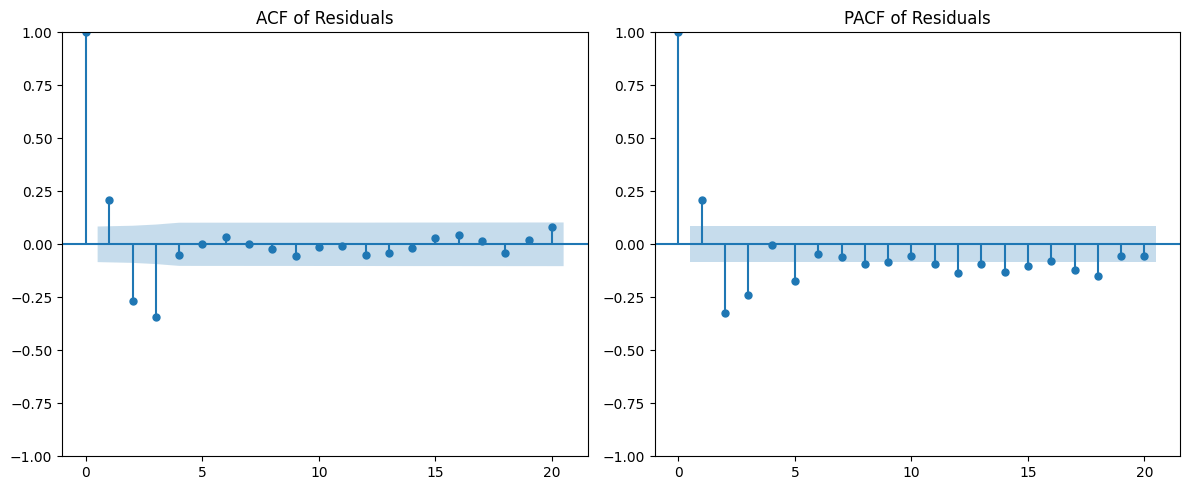

In [32]:
residual_series = df_residual['Residual'].dropna()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_acf(residual_series, lags=20, ax=plt.gca())
plt.title('ACF of Residuals')

plt.subplot(1,2,2)
plot_pacf(residual_series, lags=20, ax=plt.gca())
plt.title('PACF of Residuals')

plt.tight_layout()
plt.show()

We use ACF to select q (MA term) and PACF to select p (AR term).

ACF: Lag 1 positive, lags 2–3 negative → q = 2

PACF: Lags 1–3 significant, lag 4 ~0 → p = 2

Although we have already decomposed the time series and examined the ACF and PACF of the residuals, it is also important to analyze the original series. By plotting the ACF and PACF for the data before decomposition (using df_english), we can better determine the appropriate AR (p) and MA (q) orders for the ARIMA model. Additionally, we will perform first-order differencing on the series to check for stationarity, which will help confirm whether differencing is needed within the ARIMA model itself.

## Differencing

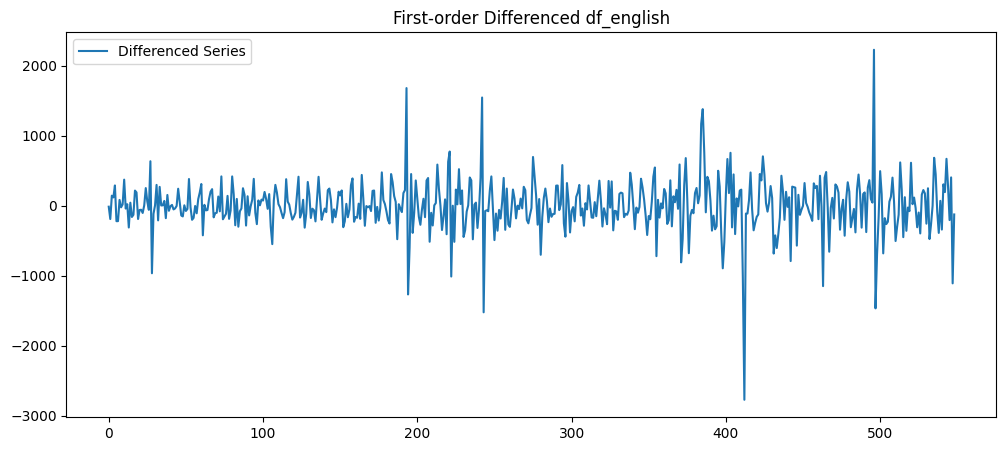

ADF Statistic: -8.28598267595906
p-value: 4.3896299044672177e-13
Critical Values: {'1%': np.float64(-3.4426321555520905), '5%': np.float64(-2.86695748394138), '10%': np.float64(-2.5696553279762426)}


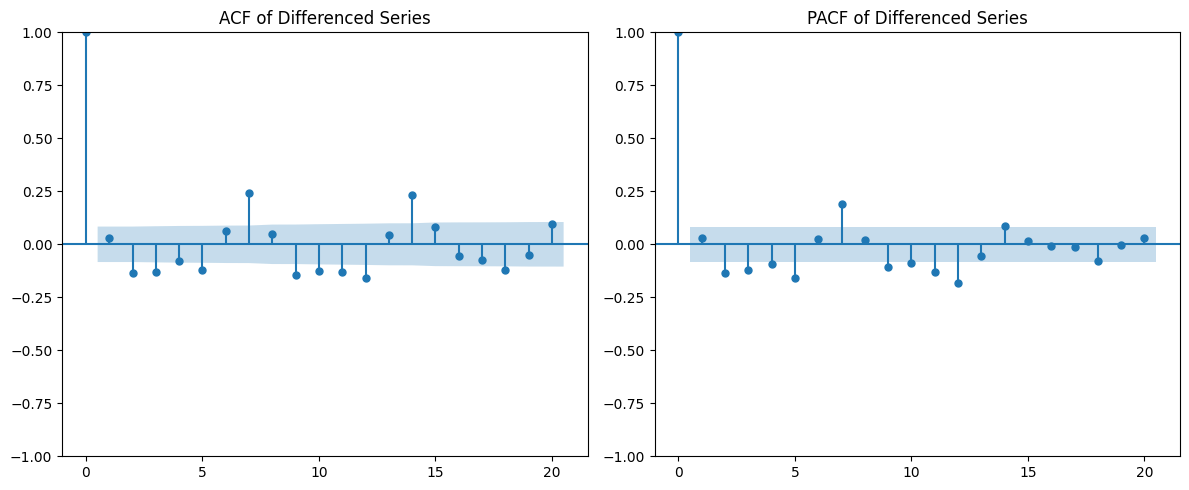

In [33]:
ts = df_english.reset_index(drop=True).dropna()
ts_diff = ts - ts.shift(1)
ts_diff = ts_diff.dropna()

plt.figure(figsize=(12,5))
plt.plot(ts_diff.values, label='Differenced Series')
plt.title('First-order Differenced df_english')
plt.legend()
plt.show()

adf_result = adfuller(ts_diff)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(ts_diff, lags=20, ax=plt.gca())
plt.title('ACF of Differenced Series')

plt.subplot(1,2,2)
plot_pacf(ts_diff, lags=20, ax=plt.gca())
plt.title('PACF of Differenced Series')

plt.tight_layout()
plt.show()

The ADF test on the first-order differenced series gives an ADF Statistic of -8.286 and a p-value of 4.39 × 10⁻¹³, well below the 0.05 significance level, indicating that the differenced series is stationary.

By analyzing the ACF and PACF plots, we determine the ARIMA orders as p = 1 (from PACF) and q = 1 (from ACF). However, we also observe some seasonality, as weekly lags in the ACF are significantly high. This seasonal component will be addressed in the subsequent modeling steps.

# Time Series Forecasting

## ARIMA

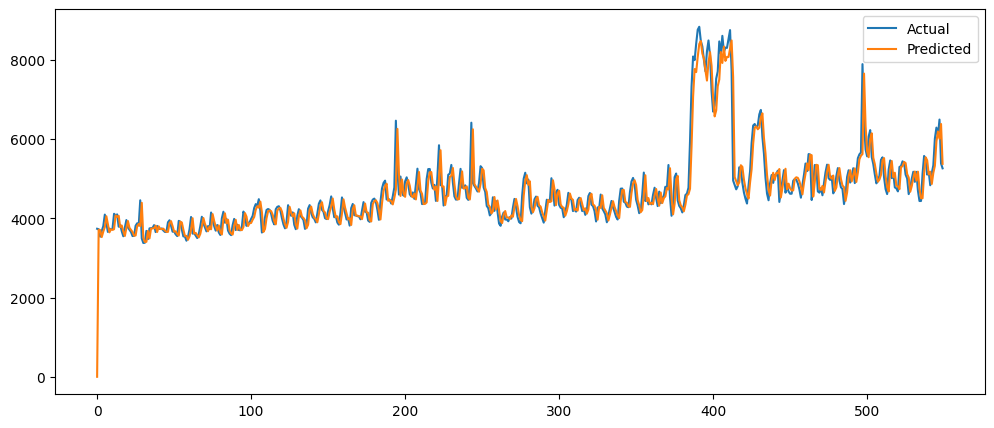

In [34]:
model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

pred = model_fit.predict(start=0, end=len(ts)-1, dynamic=False)

plt.figure(figsize=(12,5))
plt.plot(ts, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.show()

In [35]:
mape = np.mean(np.abs(pred - ts) / np.abs(ts)) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 5.16%


### ARIMA Multistep forecasting

MAPE: 7.21%


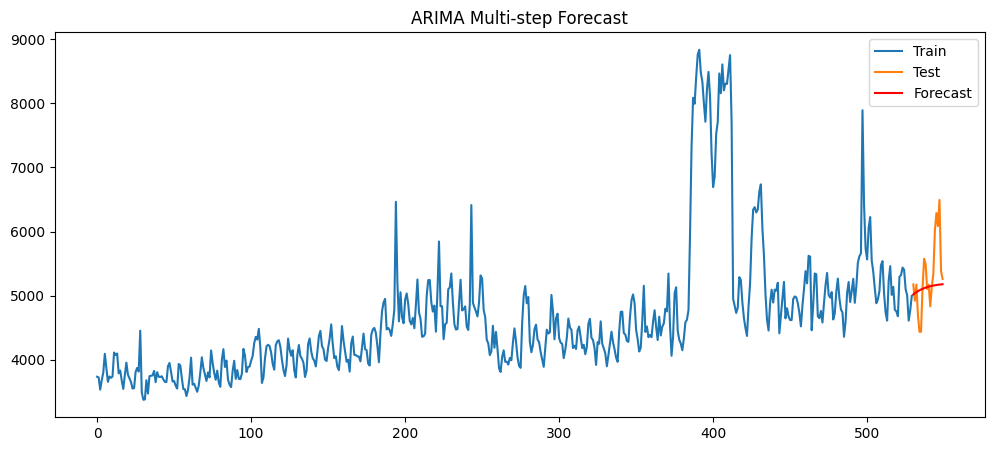

In [36]:
train = ts[:-20]
test = ts[-20:]

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

mape = np.mean(np.abs((test - forecast) / test)) * 100
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.title('ARIMA Multi-step Forecast')
plt.legend()
plt.show()

The ARIMA(1,1,1) model performs reasonably well on the dataset. The training MAPE of 5.16% indicates that the model fits the historical data closely, while the testing MAPE of 7.21% during multi-step forecasting suggests that the model can predict future values with acceptable accuracy, though some deviation exists.

However, the ACF plots of the differenced series show significant spikes at weekly lags, indicating the presence of seasonality in the data. Standard ARIMA captures trends and short-term dependencies but does not explicitly handle seasonal patterns.

To address this, we will build a SARIMA model, which incorporates seasonal autoregressive and moving average components to better capture both trend and seasonal effects in the dataset.

## SARIMA

SARIMA MAPE: 8.90%


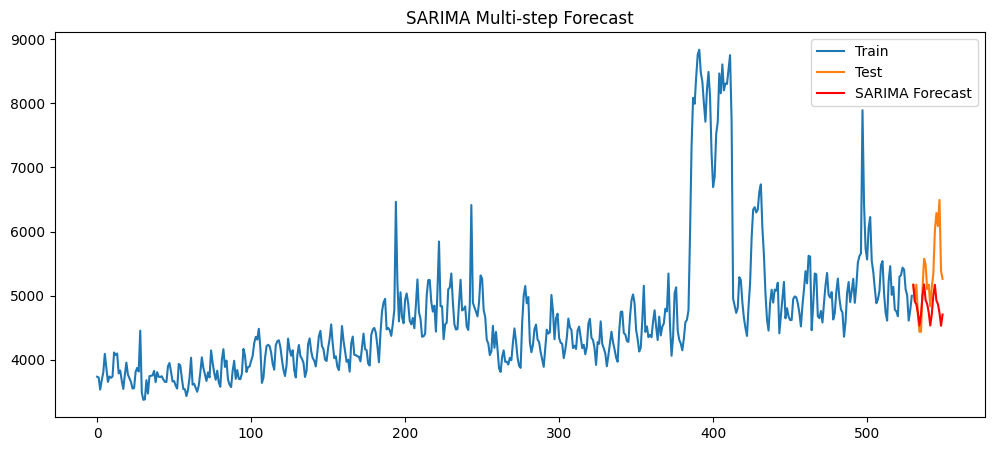

In [37]:
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7))
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=len(test))
mape = np.mean(np.abs((test - sarima_forecast) / test)) * 100
print(f"SARIMA MAPE: {mape:.2f}%")

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast', color='red')
plt.title('SARIMA Multi-step Forecast')
plt.legend()
plt.show()

The SARIMA model, which accounts for both trend and seasonality in the data, produced a MAPE of 8.90% on the test set. While this represents a clear improvement over the basic ARIMA model, the residual analysis and observed spikes during holiday periods suggest that external factors such as holidays significantly influence the series. To capture these effects, we include a holiday indicator as an exogenous variable in the next step, extending the SARIMA framework to SARIMAX. This allows the model to account for both seasonal patterns and the impact of external events, improving forecast accuracy.

## SARIMAX

SARIMAX MAPE: 3.58%


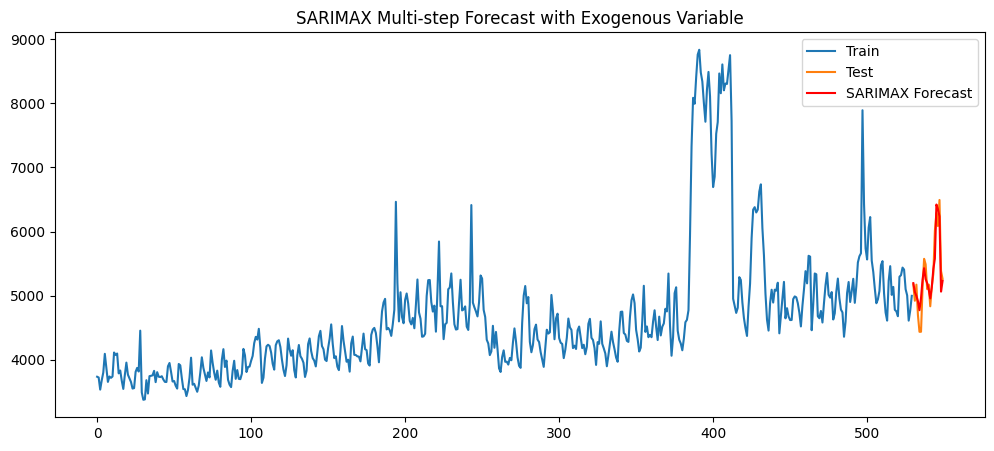

In [38]:
train = ts[:-20]
test = ts[-20:]

exog_train = df2['Exog'][:-20]
exog_test = df2['Exog'][-20:]

sarimax_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    exog=exog_train
)
sarimax_fit = sarimax_model.fit(disp=False)


sarimax_forecast = sarimax_fit.forecast(steps=len(test), exog=exog_test)

mape = np.mean(np.abs((test - sarimax_forecast) / test)) * 100
print(f"SARIMAX MAPE: {mape:.2f}%")

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, sarimax_forecast, label='SARIMAX Forecast', color='red')
plt.title('SARIMAX Multi-step Forecast with Exogenous Variable')
plt.legend()
plt.show()


After incorporating the holiday indicator as an exogenous variable in the SARIMAX model, the MAPE dropped significantly to 3.58%, demonstrating a substantial improvement over the SARIMA model. This highlights the strong influence of holidays on the time series, which could not be fully captured by trend and seasonality alone. By including relevant external factors, the SARIMAX model provides more accurate and reliable forecasts, making it a powerful approach for datasets affected by external events.

Building on the improvements seen with SARIMAX, we now explore Prophet, a model specifically designed to handle time series with trend, seasonality, and external regressors such as holidays. Prophet automatically models seasonal patterns and can incorporate additional covariates, making it well-suited to datasets where external events significantly impact the series. By applying Prophet with the same holiday indicator, we can evaluate whether it further enhances forecast accuracy and provides complementary insights alongside the SARIMAX approach.

## Prophet

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet MAPE with Exogeneous variable: 6.79%


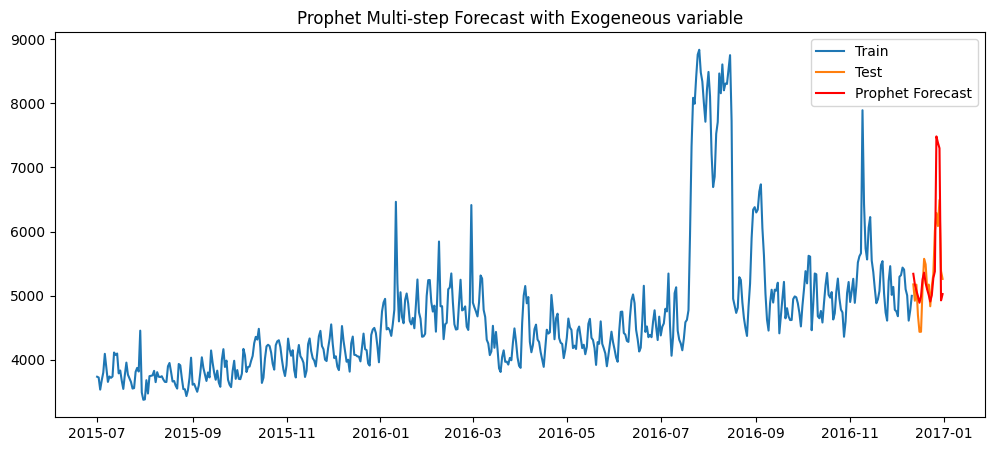

In [39]:
df_prophet = pd.DataFrame({
    'ds': pd.to_datetime(df_english.index),
    'y': df_english.values,
    'holiday': df2['Exog'].values
})

train_prophet = df_prophet[:-20]
test_prophet = df_prophet[-20:]

model = Prophet()
model.add_regressor('holiday')
model.fit(train_prophet)

future = model.make_future_dataframe(periods=20)
future['holiday'] = pd.concat([
    df_prophet['holiday'],
    df2['Exog'].iloc[-20:]
]).reset_index(drop=True)

forecast = model.predict(future)
forecast_test = forecast[-20:]['yhat'].values

mape = mean_absolute_percentage_error(test_prophet['y'], forecast_test) * 100
print(f"Prophet MAPE with Exogeneous variable: {mape:.2f}%")

plt.figure(figsize=(12,5))
plt.plot(train_prophet['ds'], train_prophet['y'], label='Train')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Test')
plt.plot(test_prophet['ds'], forecast_test, label='Prophet Forecast', color='red')
plt.title('Prophet Multi-step Forecast with Exogeneous variable')
plt.legend()
plt.show()


## MAPE Evaluation

The model performance across different approaches is as follows:

ARIMA(1,1,1): Training MAPE = 5.16%, Testing MAPE = 7.21%

SARIMA(1,1,1)(1,1,1,7): Testing MAPE = 8.90%

SARIMAX with exogenous variable: Testing MAPE = 3.58%

Prophet with exogenous variable: Testing MAPE = 6.79%

Key insights:

The basic ARIMA model performs reasonably well but does not explicitly capture seasonality, as reflected in the slightly higher test MAPE.

SARIMA, which incorporates seasonal components, surprisingly shows a higher test MAPE (8.90%). This indicates that while seasonality is present, it alone does not fully explain the variations in the series, particularly during periods affected by external factors.

SARIMAX, by including the exogenous variable, achieves the lowest MAPE (3.58%), demonstrating the critical importance of external factors in this dataset. Trend and seasonality alone cannot fully capture these effects.

Prophet with the exogenous variable improves over SARIMA and ARIMA (MAPE = 6.79%) but does not outperform SARIMAX. While Prophet effectively models trend, seasonality, and external regressors, SARIMAX is better suited for this dataset and the way the exogenous variable impacts it.

Overall, these results emphasize that incorporating relevant exogenous variables is crucial for accurate forecasting, with SARIMAX providing the most reliable predictions among the models tested.

# Pipeline For Other Languages

This pipeline provides a modular framework to forecast Wikipedia page views for multiple languages, excluding English and Unknown. For each language, the pipeline first checks stationarity using the ADF test and applies first-order differencing if needed. It then visualizes autocorrelations using ACF and PACF plots to guide model selection. The dataset is split into train and test sets, with the last few days used for testing. Forecasts are generated using three models: ARIMA (default order 1,1,1), SARIMA (default weekly seasonality 1,1,1,7), and Prophet (with yearly and weekly seasonality enabled by default). Prediction accuracy is quantified using MAPE, and plots are generated to compare actual vs predicted values.


Processing Language: Chinese


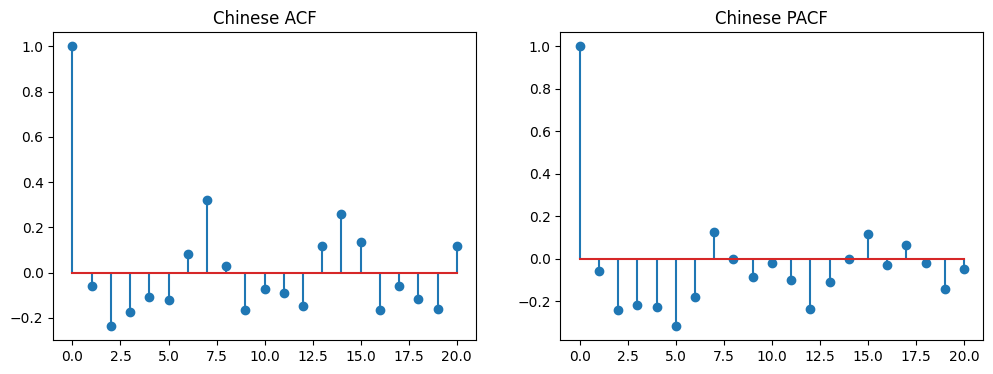

 → Running ARIMA for Chinese (params={})


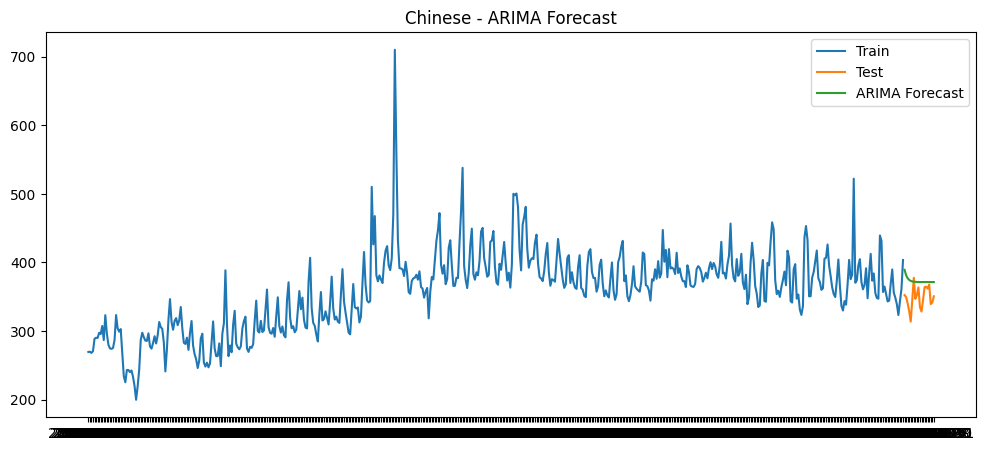

 → Running SARIMA for Chinese (params={})


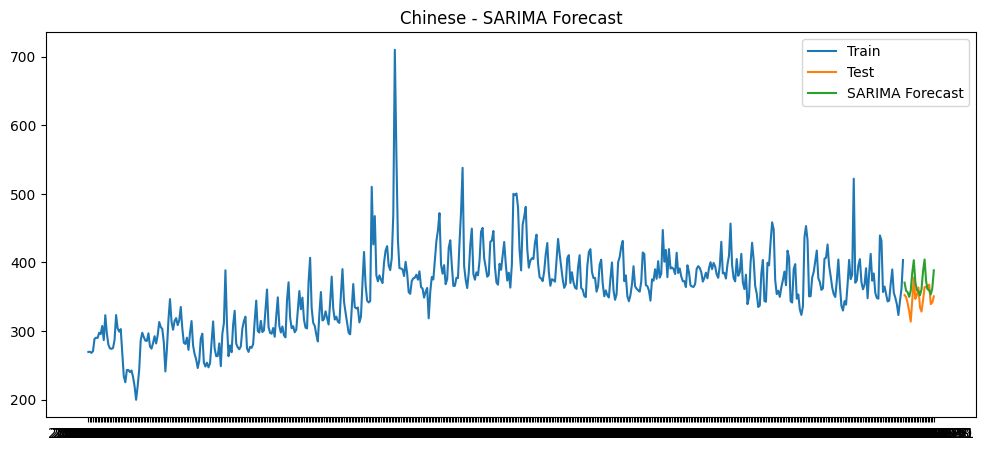

 → Running PROPHET for Chinese (params={})


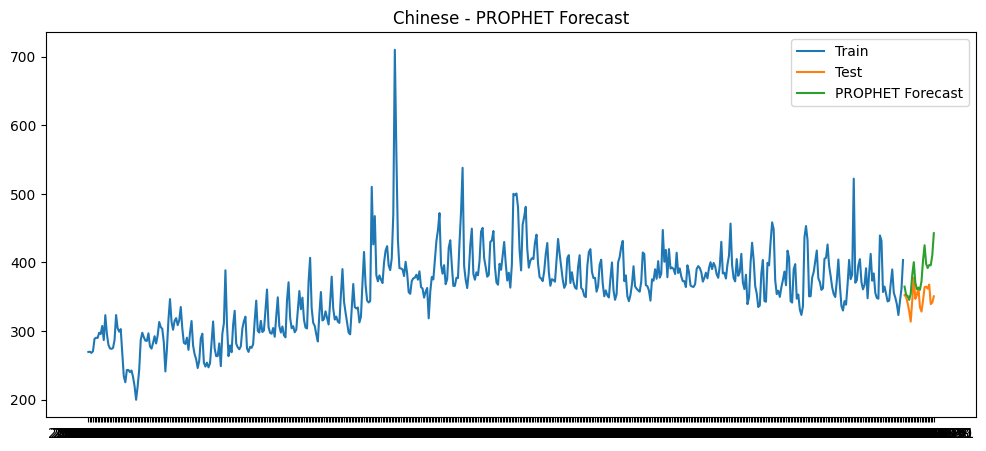


Processing Language: Corsican


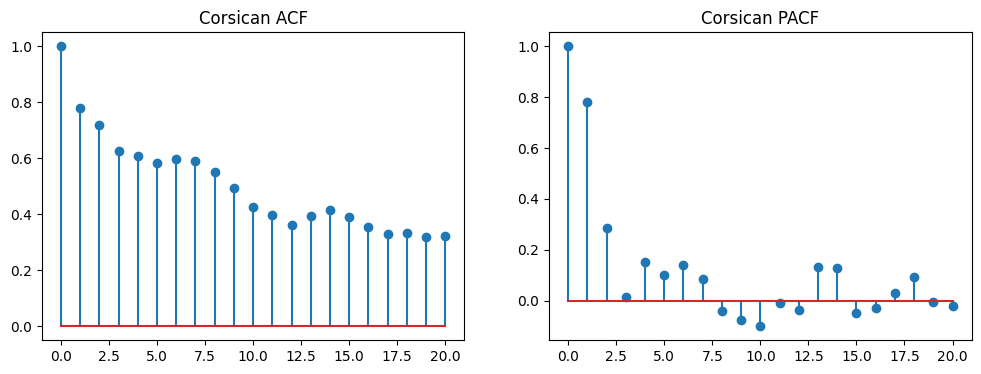

 → Running ARIMA for Corsican (params={})


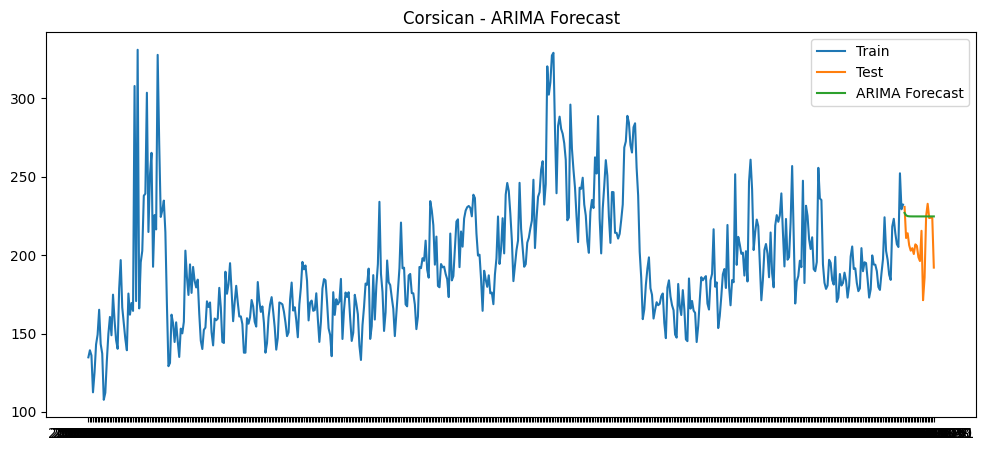

 → Running SARIMA for Corsican (params={})


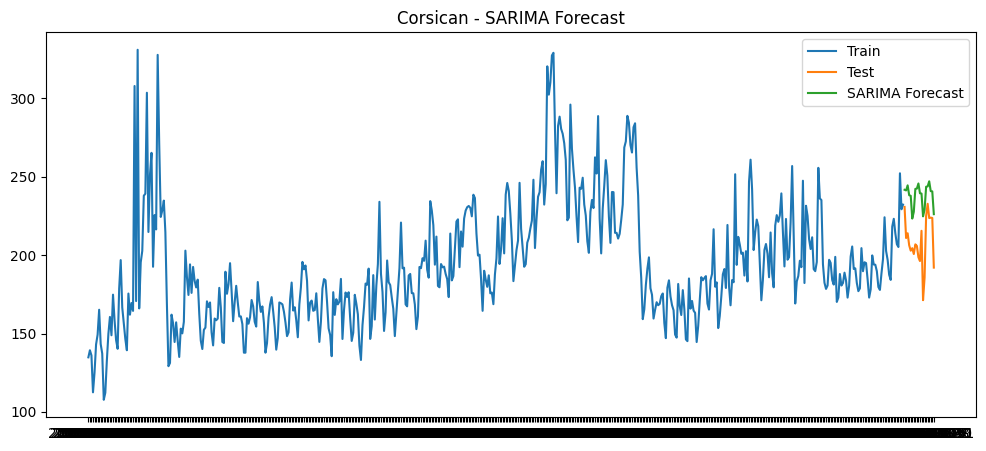

 → Running PROPHET for Corsican (params={})


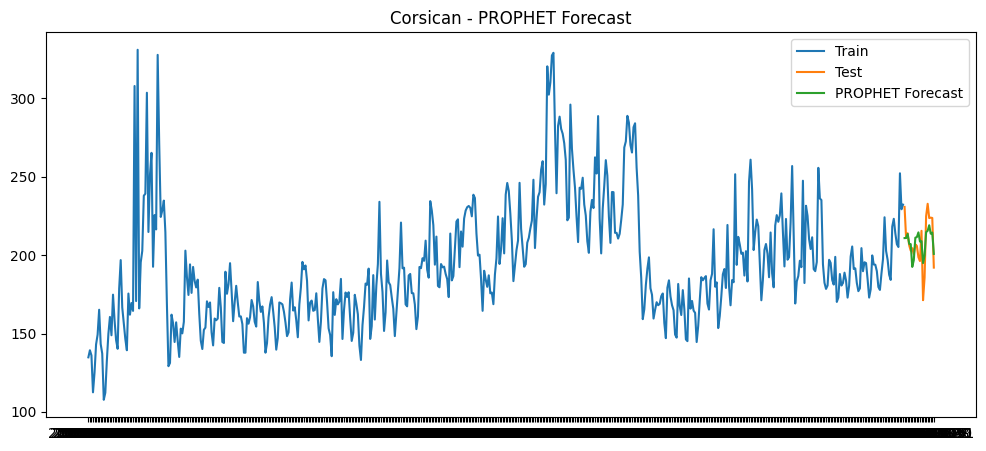


Processing Language: French


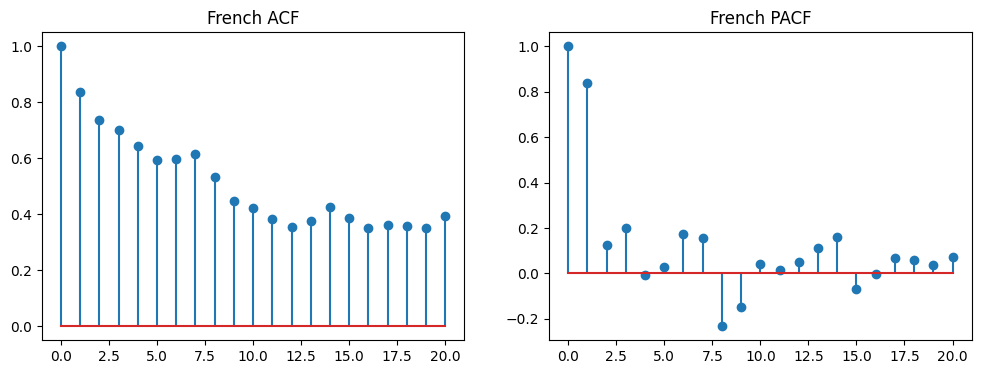

 → Running ARIMA for French (params={})


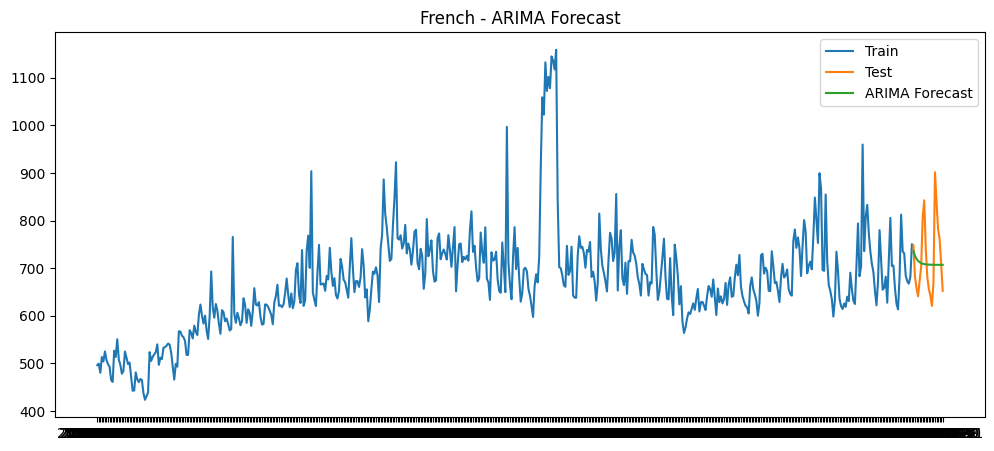

 → Running SARIMA for French (params={})


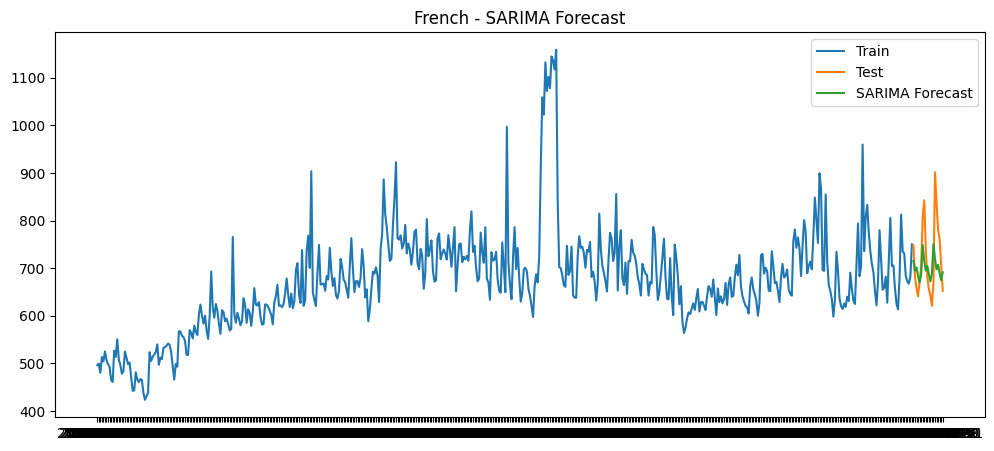

 → Running PROPHET for French (params={})


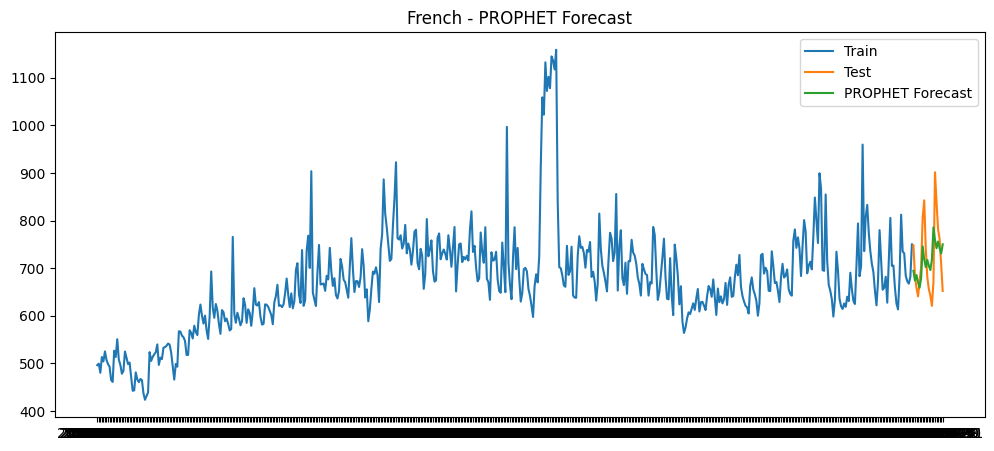


Processing Language: German


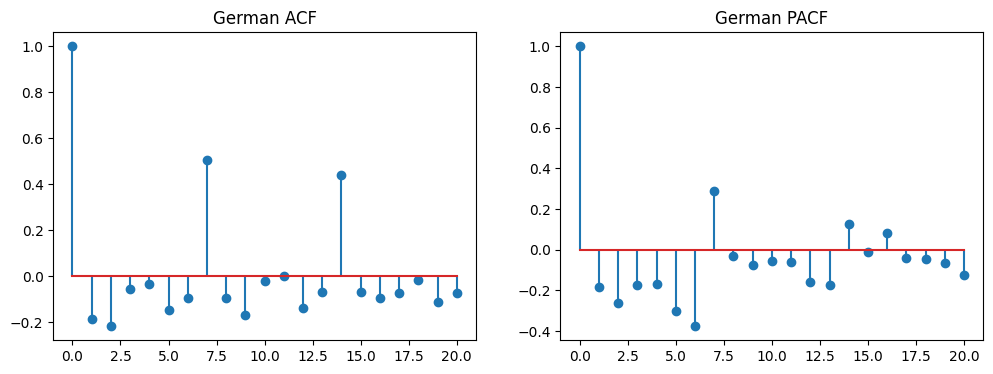

 → Running ARIMA for German (params={})


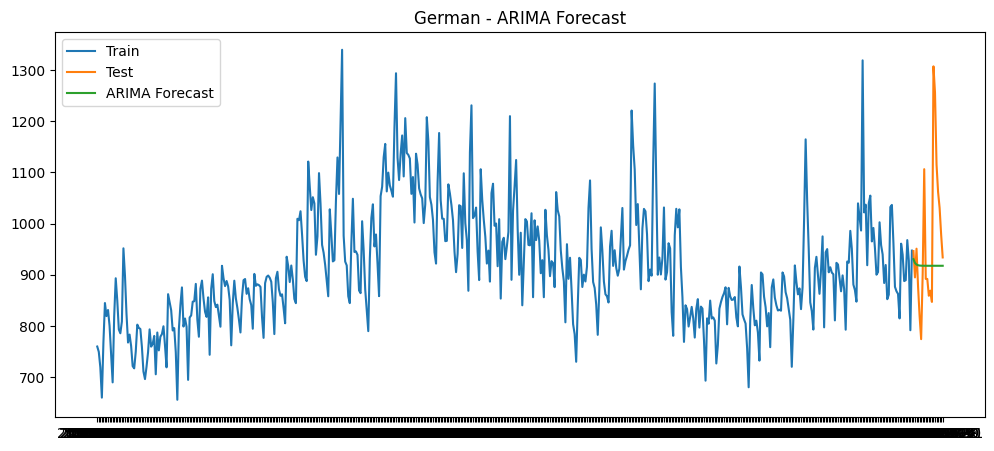

 → Running SARIMA for German (params={})


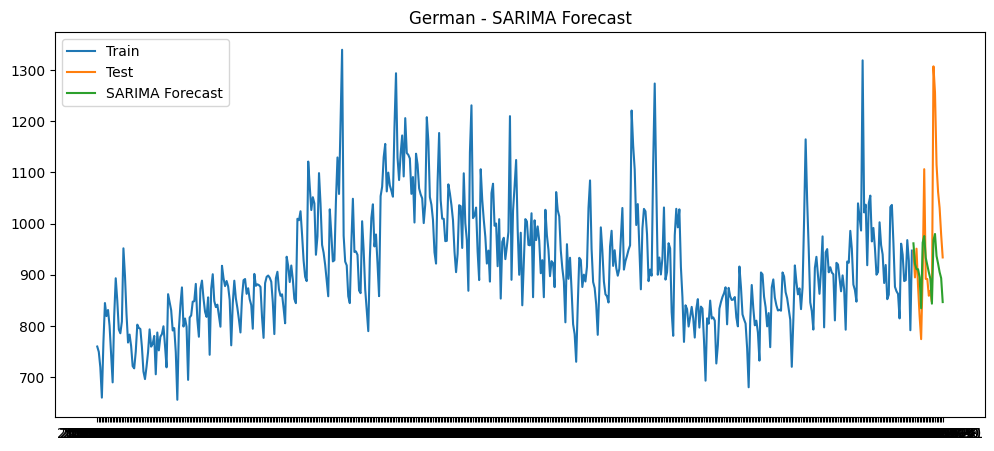

 → Running PROPHET for German (params={})


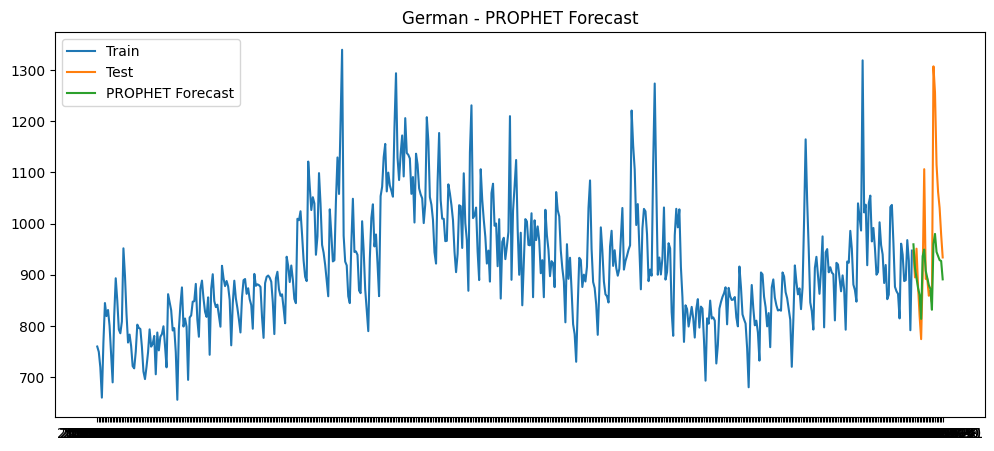


Processing Language: Japanese


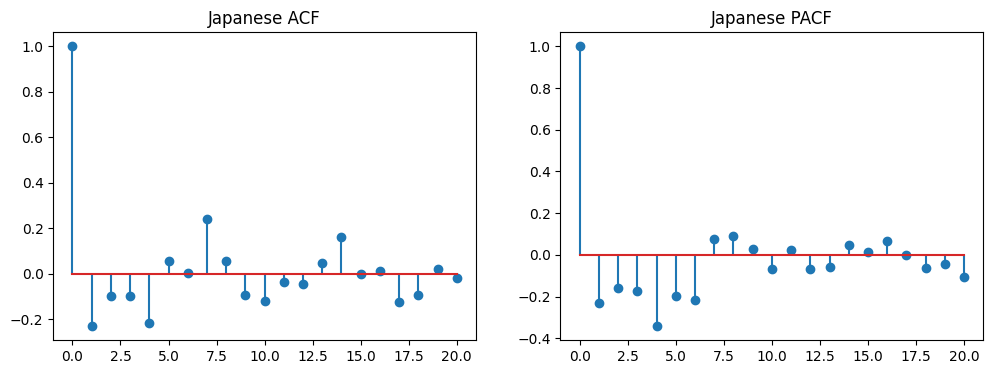

 → Running ARIMA for Japanese (params={})


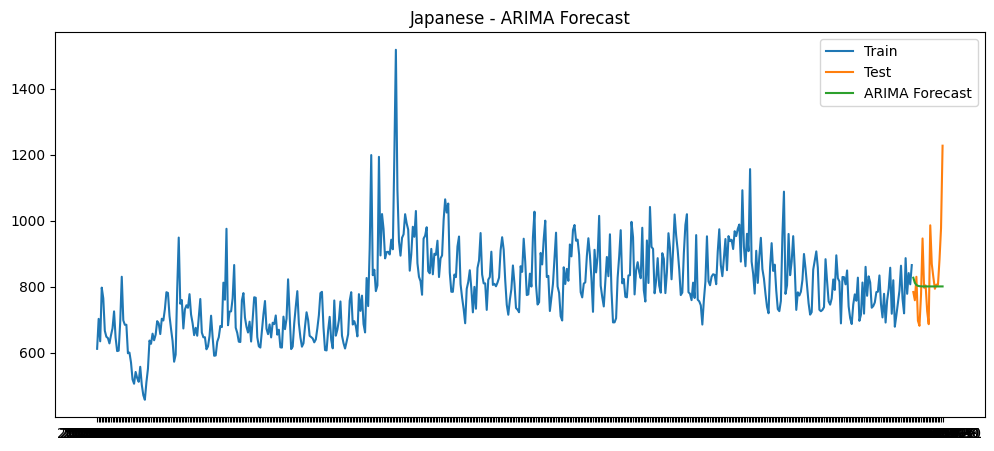

 → Running SARIMA for Japanese (params={})


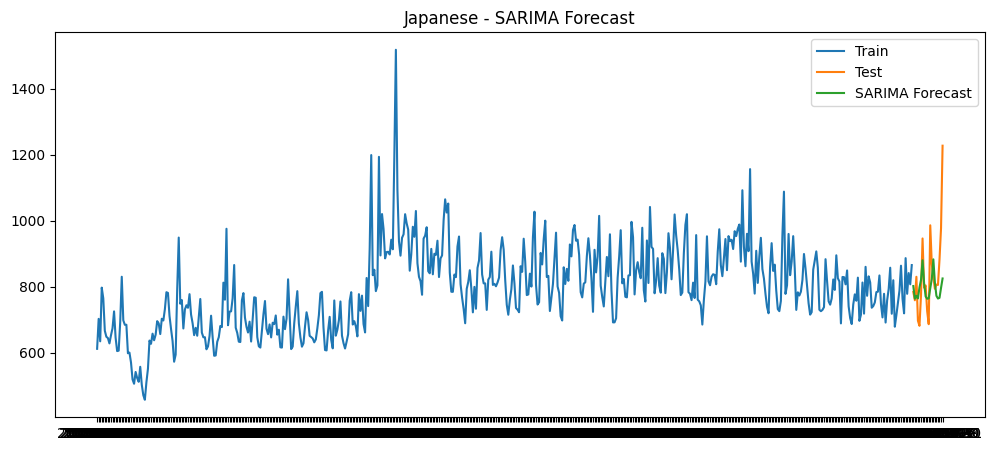

 → Running PROPHET for Japanese (params={})


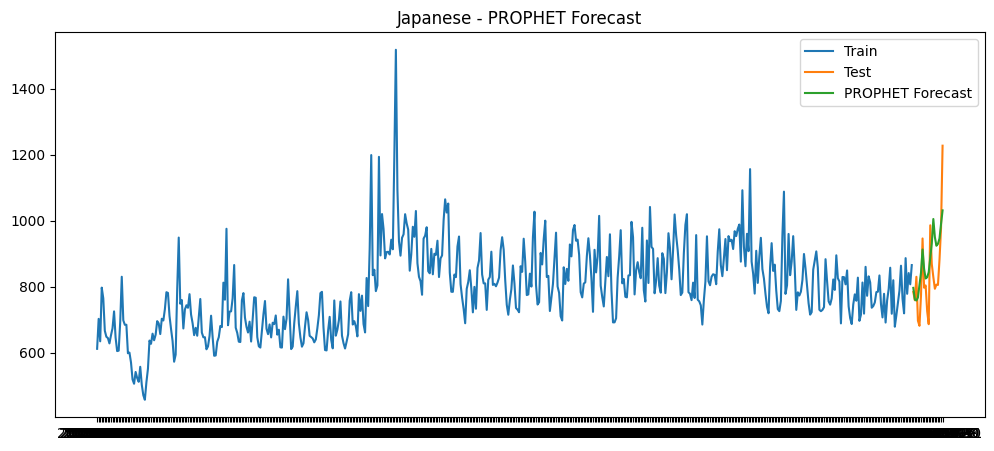


Processing Language: Russian


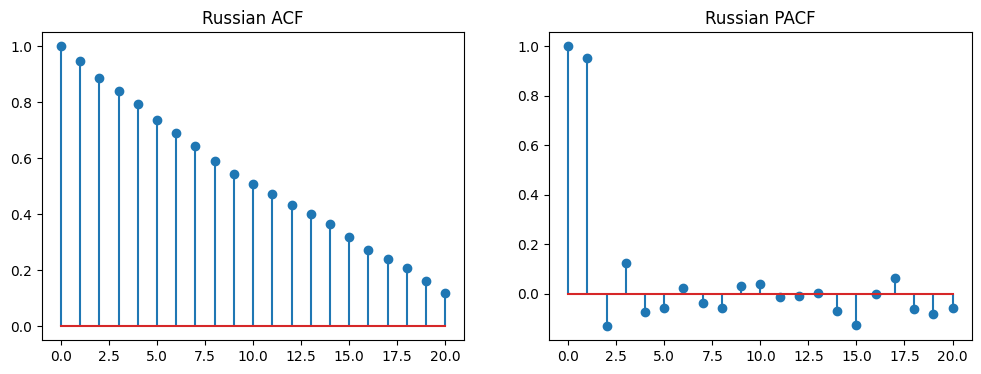

 → Running ARIMA for Russian (params={})


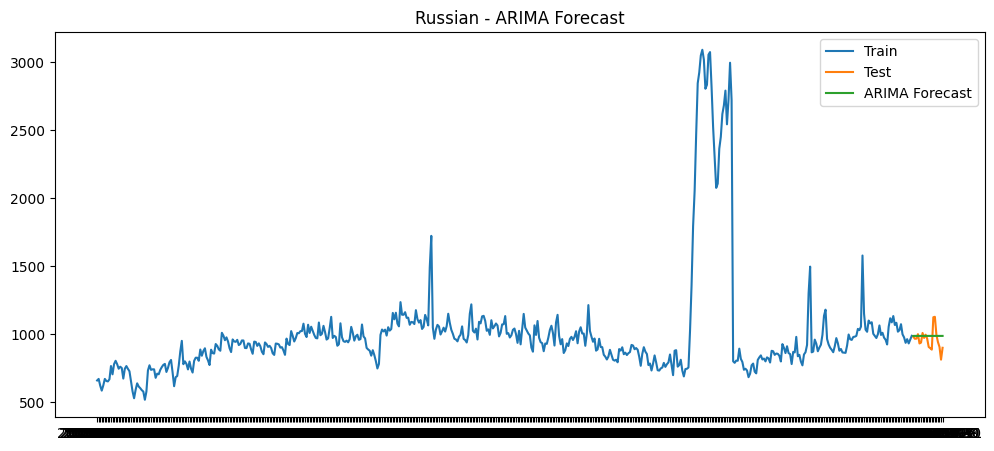

 → Running SARIMA for Russian (params={})


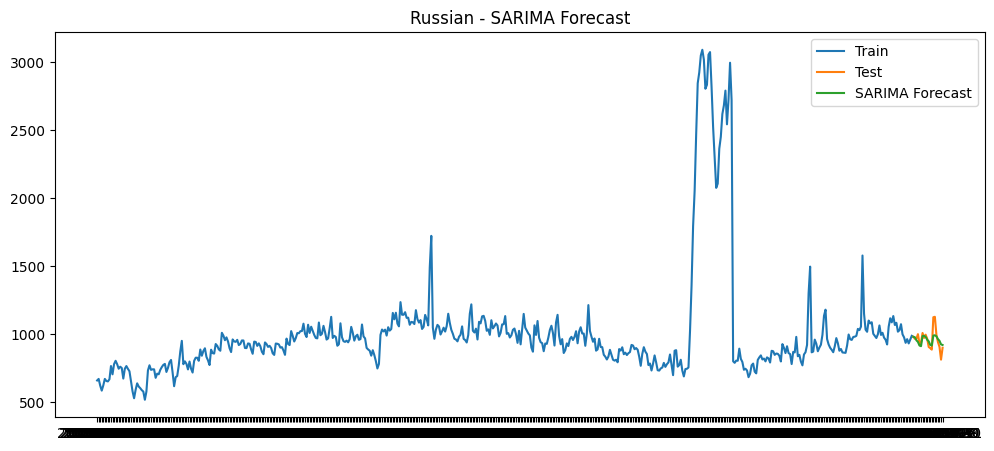

 → Running PROPHET for Russian (params={})


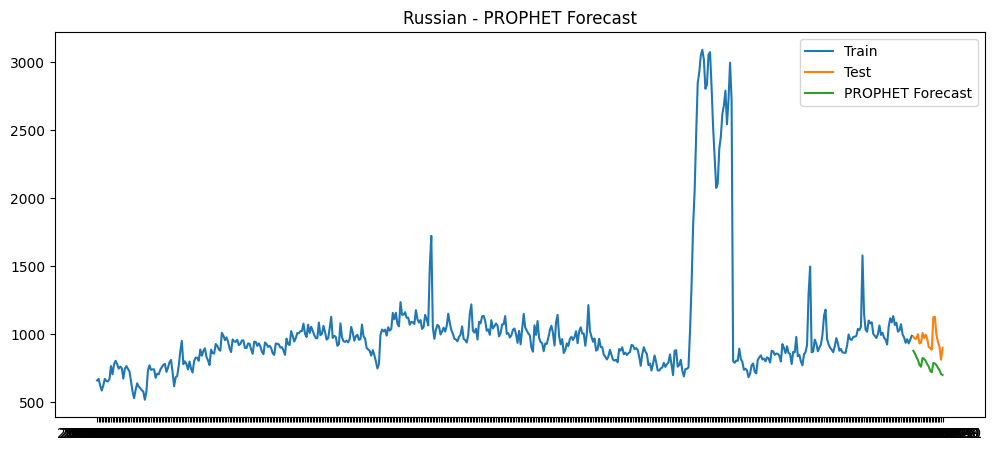


Processing Language: Spanish


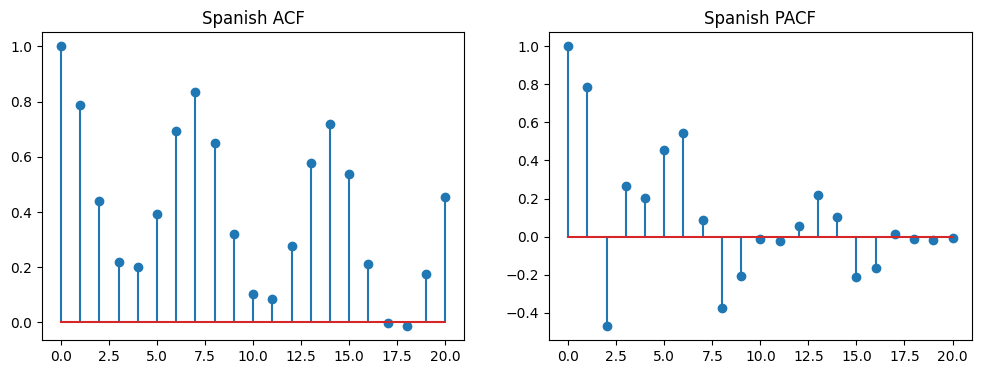

 → Running ARIMA for Spanish (params={})


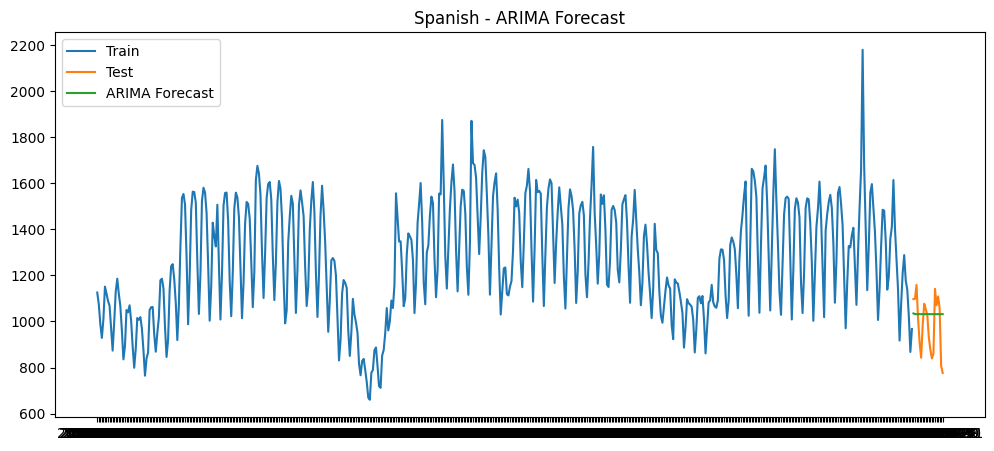

 → Running SARIMA for Spanish (params={})


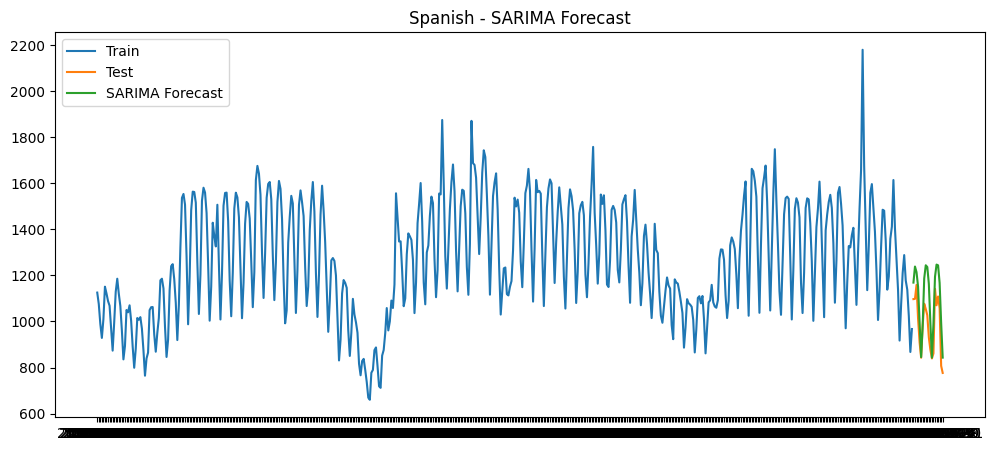

 → Running PROPHET for Spanish (params={})


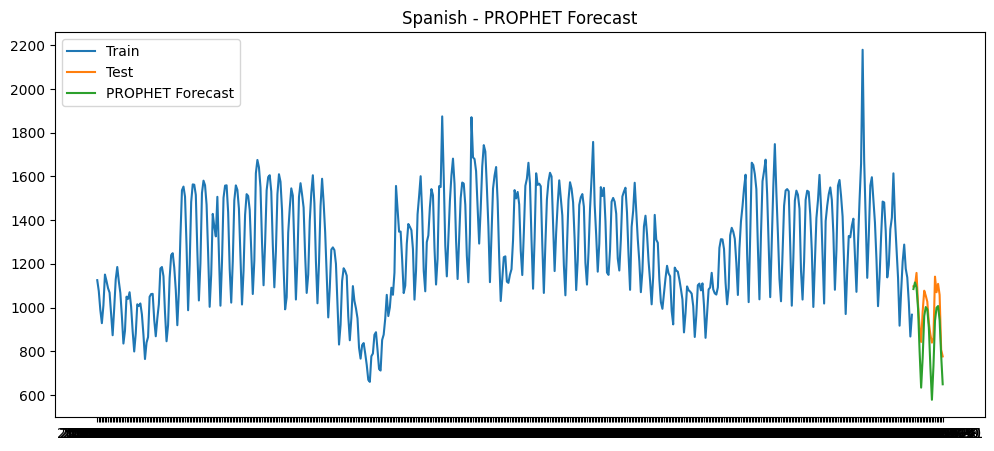

         ARIMA_MAPE SARIMA_MAPE PROPHET_MAPE
Language                                    
Chinese       7.53%       6.31%        9.75%
Corsican      8.94%      14.57%        4.50%
French        8.61%       7.66%        7.77%
German        9.78%       8.57%        6.99%
Japanese      9.45%       8.97%       10.54%
Russian       6.24%       3.90%       18.66%
Spanish      11.34%      11.27%       10.83%


In [40]:
# Environment and Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from prophet import Prophet

#   Utility Functions
def safe_mape(y_true, y_pred):
    """Calculate MAPE safely, avoiding division by zero."""
    y_true_safe = np.where(y_true == 0, 1e-6, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100


def check_stationarity(ts):
    """Check stationarity and apply first-order differencing if needed."""
    adf_result = adfuller(ts)
    if adf_result[1] > 0.05:
        return ts.diff().dropna(), True
    return ts, False


def plot_acf_pacf(ts, title):
    lag_acf = acf(ts, nlags=20)
    lag_pacf = pacf(ts, nlags=20)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.stem(lag_acf)
    plt.title(f"{title} ACF")

    plt.subplot(1, 2, 2)
    plt.stem(lag_pacf)
    plt.title(f"{title} PACF")

    plt.show()

#Models
def run_arima(train, test, params):
    """Fit ARIMA model & return forecast + MAPE."""
    try:
        p, d, q = params.get("order", (1, 1, 1))
        model = ARIMA(train, order=(p, d, q))
        fit = model.fit()
        pred = fit.forecast(steps=len(test))
        mape = safe_mape(test.values, pred.values)
        return pred, mape
    except Exception as e:
        print(f"[ARIMA ERROR] {e}")
        return None, np.nan


def run_sarima(train, test, params):
    """Fit SARIMA model & return forecast + MAPE."""
    try:
        order = params.get("order", (1, 1, 1))
        seasonal = params.get("seasonal_order", (1, 1, 1, 7))
        model = SARIMAX(train, order=order, seasonal_order=seasonal)
        fit = model.fit(disp=False)
        pred = fit.forecast(steps=len(test))
        mape = safe_mape(test.values, pred.values)
        return pred, mape
    except Exception as e:
        print(f"[SARIMA ERROR] {e}")
        return None, np.nan


def run_prophet(train, test, params):
    """Fit Prophet model & return forecast + MAPE."""
    try:
        df_p = pd.DataFrame({"ds": train.index, "y": train.values})
        model = Prophet(
            yearly_seasonality=params.get("yearly_seasonality", True),
            weekly_seasonality=params.get("weekly_seasonality", True),
            daily_seasonality=params.get("daily_seasonality", False),
        )
        model.fit(df_p)

        future = model.make_future_dataframe(periods=len(test))
        forecast = model.predict(future)
        pred = forecast["yhat"].iloc[-len(test):].values

        mape = safe_mape(test.values, pred)
        return pred, mape
    except Exception as e:
        print(f"[PROPHET ERROR] {e}")
        return None, np.nan


MODEL_REGISTRY = {
    "arima": run_arima,
    "sarima": run_sarima,
    "prophet": run_prophet
}

#Plot
def plot_results(train, test, predictions, model_name, lang):
    plt.figure(figsize=(12, 5))
    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Test")
    if predictions is not None:
        plt.plot(test.index, predictions, label=f"{model_name.upper()} Forecast")
    plt.title(f"{lang} - {model_name.upper()} Forecast")
    plt.legend()
    plt.show()


#Pipeline
def multi_language_pipeline(
    df_language,
    forecast_steps=20,
    plot=True,
    models_to_run=("arima", "sarima", "prophet"),
    hyperparams=None,
):
    """
    Modular forecasting pipeline.

    hyperparams example:
    {
        "Hindi": {
            "arima": {"order": (2,1,2)},
            "sarima": {"order": (1,1,1), "seasonal_order": (1,1,1,12)},
            "prophet": {"yearly_seasonality": True}
        },
        "Tamil": {
            "arima": {"order": (3,1,1)}
        }
    }
    """
    hyperparams = hyperparams or {}

    df_language = df_language.drop(columns=["Unknown", "English"], errors="ignore")
    results = []

    for lang in df_language.columns:
        print(f"\n==============================")
        print(f"Processing Language: {lang}")
        print(f"==============================")

        ts = df_language[lang].dropna()
        if len(ts) < 30:
            print(f"{lang} skipped (series too short)")
            continue

        ts_diff, differenced = check_stationarity(ts)
        if plot:
            plot_acf_pacf(ts_diff, lang)

        train = ts[:-forecast_steps]
        test = ts[-forecast_steps:]

        lang_params = hyperparams.get(lang, {})

        lang_results = {"Language": lang}

        for model_name in models_to_run:
            model_func = MODEL_REGISTRY[model_name]
            model_params = lang_params.get(model_name, {})  # default empty → default params used

            print(f" → Running {model_name.upper()} for {lang} (params={model_params})")

            predictions, mape = model_func(train, test, model_params)

            if plot:
                plot_results(train, test, predictions, model_name, lang)

            lang_results[f"{model_name.upper()}_MAPE"] = mape

        results.append(lang_results)

    df_results = pd.DataFrame(results).set_index("Language")
    df_results = df_results.applymap(lambda x: f"{x:.2f}%" if pd.notnull(x) else "NaN")

    return df_results

results = multi_language_pipeline(df_language)
print(results)


## Model Performance Across Languages

Default parameters were used for ARIMA, SARIMA, and Prophet models. Key observations:

- **Chinese:** SARIMA performs best (6.31% MAPE), slightly better than ARIMA (7.53%), Prophet slightly worse (9.75%).  
- **Corsican:** Prophet (4.50% MAPE) outperforms ARIMA (8.94%) and SARIMA (14.57%), showing flexibility benefits for low-volume series.  
- **French & German:** ARIMA and SARIMA perform comparably; Prophet slightly worse for French (7.77%) but best for German (6.99%).  
- **Japanese:** All models show similar MAPE (~9–10%), suggesting standard seasonal patterns are insufficient to fully capture dynamics.  
- **Russian:** SARIMA performs exceptionally well (3.90%), highlighting strong seasonal effects; Prophet overestimates variability (18.66%) due to low-volume fluctuations.  
- **Spanish:** All models have high MAPE (~11–11.3%), reflecting irregular or volatile traffic patterns not captured by default settings.  

**Insight:** SARIMA works well for languages with strong seasonality, Prophet is suitable for low-volume or irregular series, and ARIMA provides a baseline forecast. Hyperparameter tuning o



## Pipeline Overview

The multi-language forecasting pipeline provides a modular, scalable, and reproducible framework to model page views across different languages.

- **Supported Models:** ARIMA, SARIMA, and Prophet, covering baseline, seasonal, and flexible trend-based forecasting.
- **Hyperparameter Flexibility:** Default model parameters provide a baseline forecast, but users can pass language-specific hyperparameters (ARIMA/SARIMA orders, seasonal patterns, Prophet seasonality) for improved accuracy.
- **Preprocessing & Diagnostics:** Automatically checks stationarity, applies differencing if needed, and plots ACF/PACF to guide model understanding.
- **Forecast Evaluation:** Calculates MAPE as the primary error metric and optionally SMAPE for low-volume languages to provide a balanced error measure.
- **Visualization & Interpretation:** Produces forecast plots for each language and a summary table of error metrics for quick insights and comparisons.
- **Scalability:** Designed to handle multiple language time series efficiently, making it easy to extend to additional languages or larger datasets.
- **Experimentation Ready:** Users can adjust forecast horizons, select models to run, and experiment with hyperparameters without modifying the core pipeline.


## Pipeline Usage & Applications
The pipeline supports a range of practical applications:

- **Multi-Language Forecasting:** Generate forecasts for multiple languages efficiently and visualize trends.  
- **Model Experimentation:** Tune hyperparameters per language (ARIMA/SARIMA orders, Prophet seasonality) without modifying core code.  
- **Decision Support:** Identify seasonal patterns, peaks, and irregular behavior to guide content planning, marketing campaigns, or resource allocation.  
- **Performance Evaluation:** Compare ARIMA, SARIMA, and Prophet models to select the best-performing model per language.



## Pipeline Extensions & Enhancements
Potential improvements to increase forecast accuracy and usability include:

- **Hyperparameter Optimization:** Integrate Auto-ARIMA or grid search to fine-tune model parameters (computationally intensive).  
- **Exogenous Variables:** Incorporate language-specific holidays, events, or other external factors to reduce forecast error.  
- **Alternative Metrics:** Use SMAPE for low-volume languages to balance relative percentage errors.  
- **Flexible Forecast Horizons:** Adjust the forecast length to support short-term tactical decisions or long-term strategic planning.



# Recommendations for AdEase – Multi-Language Forecasting

## Traffic & Engagement Patterns
- Overall traffic shows clear segmentation:
  - **High-volume:** English dominates with stable, cyclical views.  
  - **Medium-volume:** German, Russian, Spanish show moderate, fluctuating engagement.  
  - **Low-volume:** French, Chinese, Japanese, Corsican exhibit flatter, irregular patterns.  
- Peaks are event-driven (e.g., July–August, December–January), suggesting content timing impacts engagement.

## Model Performance Insights
- Default ARIMA, SARIMA, and Prophet models provide baseline forecasts.  
- SARIMAX with exogenous variables on English demonstrates significant improvement, highlighting the value of external factors.  
- Other languages still show high MAPE in some cases, indicating room for improvement through tuning and additional inputs.  

## Actionables
- **Hyperparameter Tuning:** Customize ARIMA/SARIMA orders and Prophet seasonality per language for better accuracy.  
- **Exogenous Variables:** Include holidays, events, or campaigns relevant to each language to capture external influences.  
- **Model Selection:** Use SARIMA for predictable seasonal trends, Prophet for low-volume/irregular data, ARIMA as a baseline.  
- **Evaluation Metrics:** Continue using MAPE; consider SMAPE for low-traffic languages.

## Strategic Applications
- Plan content and campaigns based on forecasted peaks and seasonality.  
- Allocate resources efficiently by understanding expected traffic trends.  
- Iterate model parameters and include exogenous inputs to continuously improve forecast reliability.


# Questions

## **Defining the problem statements and where can this and modifications of this be used?**

**Problem Statement:**
Build a forecasting system that analyzes multilingual Wikipedia page-view trends and predicts future engagement so AdEase can place ads where user attention will be highest. The goal is to understand historical patterns, model future demand, and segment insights by language and region to maximize ROI for clients.

**Where This Can Be Used / Extensions:**
This approach can be applied to any platform with time-based engagement data—news sites, e-commerce traffic, streaming views, or app activity—to forecast demand and optimize content or ad placement. It can also be adapted for capacity planning, campaign scheduling, anomaly detection, or personalized recommendation systems.

## **Write 3 inferences you made from the data visualizations**

1. **Seasonal Peaks:** Strong traffic spikes appear in January and July–August, indicating clear seasonal patterns across languages.

2. **Language Segmentation:** English leads with consistently high views, while German/Russian form a mid-tier and others show lower, steady engagement.

3. **Targetable Engagement Bands:** The natural split into high-, mid-, and low-view bands helps identify where user attention concentrates, guiding smarter ad targeting.

## **What does the decomposition of series do?**

Decomposition breaks the time series into trend, seasonality, and residuals to reveal underlying patterns.
In our case, no clear trend was present, but with a 7-day period the weekly seasonality was clearly visible.
The residual component was stationary, confirmed using the ADF test, showing that most structure was captured by the decomposition.


## **What level of differencing gave you a stationary series?**

A first-order differencing (d = 1) made the series stationary.
After applying one differencing step, the ADF test confirmed stationarity, indicating no further differencing was required.
Difference between arima, sarima & sarimax.

##**Compare the number of views in different languages**

English consistently receives the highest views, forming a clear top band with strong and stable engagement. German, Russian, and Spanish follow in a mid-tier group with moderate but more event-driven fluctuations. Languages like French, Chinese, Japanese, Corsican, and Unknown form the lower band, staying below 1,000 average views with flatter patterns. Overall, English dominates, while other languages show distinct but smaller peaks aligned with seasonal events.

##**What other methods other than grid search would be suitable to get the model for all languages?**

Other than grid search, several methods can help select the best model across languages:
1. **Auto-ARIMA:** Automatically selects optimal (p,d,q) using AIC/BIC without manual tuning.
2. **Rolling/Expanding Window CV:** Validates models over time to capture temporal patterns efficiently.
3. **Global Forecasting Models:** Train a single model (e.g., DeepAR, N-BEATS) for all series to scale.
4. **Cluster-Based Modeling:** Group similar series and fit one model per cluster to reduce computation.
5. **For-Loop with Constrained Auto-ARIMA:** Loop over each language or page using limited parameter ranges for faster fitting.